# Dự báo Kiệt quệ Tài chính Doanh nghiệp Niêm yết Việt Nam
## Early-Warning System bằng Machine Learning — Thiết kế Lệch Thời gian (t-1 → t)

| Thông tin | Chi tiết |
|:---|:---|
| **Dữ liệu** | 533 doanh nghiệp niêm yết Việt Nam, giai đoạn 2020–2025 (báo cáo tài chính, tỷ số CAMEL, mô hình vòng đời Dickinson, Beneish M-score) |
| **Bài toán** | Phân loại nhị phân: doanh nghiệp có rơi vào kiệt quệ tài chính (`label_distress`) năm **t** hay không |
| **Đặc trưng dự báo** | Toàn bộ chỉ số tài chính của năm **t-1** (early-warning, KHÔNG dùng dữ liệu cùng kỳ) |
| **Thuật toán** | 7 mô hình thuộc 6 nhóm: Linear (Logistic Regression), Tree & Ensemble (Decision Tree, Random Forest), Boosting (XGBoost), Distance-based (KNN), Kernel-based (SVM), Probabilistic (Naive Bayes) |

---


## Mục lục
1. Import thư viện
2. Đọc dữ liệu gốc & EDA (khám phá dữ liệu)
3. **Kiểm toán rò rỉ dữ liệu (Data Leakage Audit)** — vì sao phải thiết kế lệch thời gian
4. Xây dựng bộ dữ liệu sạch (panel t-1 → t)
5. Chia Train/Test theo thời gian & tiền xử lý
6. Nhóm 1 — Mô hình Tuyến tính: Logistic Regression
7. Nhóm 2 — Mô hình Cây quyết định & Ensemble: Decision Tree (có tinh chỉnh max_depth), Random Forest
8. Nhóm 3 — Mô hình Boosting: XGBoost
9. Nhóm 4 — Mô hình Khoảng cách: KNN (có tinh chỉnh K, khắc phục ngưỡng quyết định do không hỗ trợ `class_weight`)
10. Nhóm 5 — Mô hình Kernel: SVM
11. Nhóm 6 — Mô hình Xác suất: Naive Bayes
12. So sánh tổng hợp các mô hình (bảng, ROC/PR, Sai lầm loại I–II, xếp hạng tổng hợp, kiểm định thống kê)
13. Phân tích chuyên sâu: Feature Importance, Threshold Tuning, Odds Ratio, Dashboard tổng hợp
14. Kết luận & Hạn chế
15. Tài liệu tham khảo

## Phương pháp luận — Methodology

### Định nghĩa bài toán

| Thành phần | Mô tả |
|:---|:---|
| Biến mục tiêu | `label_distress` — 1 nếu doanh nghiệp có ≥2 tín hiệu kiệt quệ (lỗ, dòng tiền HĐKD âm, thiếu vốn lưu động, đòn bẩy cao) trong năm t |
| Biến dự báo | Toàn bộ chỉ số tài chính năm **t-1** của cùng doanh nghiệp |
| Đơn vị quan sát | (Doanh nghiệp, năm t) — panel data, 533 mã × tối đa 6 năm (2020–2025) |
| Nguồn dữ liệu | Ghép từ 4 nguồn, đều thu thập thủ công từ báo cáo tài chính kiểm toán/soát xét công bố trên **CafeF** (cafef.vn/du-lieu) và **Vietstock Finance** (finance.vietstock.vn) cho 533 doanh nghiệp niêm yết HOSE/HNX, giai đoạn 2020-2025: (1) chỉ số vòng đời doanh nghiệp theo mô hình Dickinson (1989), (2) chỉ tiêu tài chính cơ bản (fundamentals), (3) tỷ số CAMEL, (4) thành phần mô hình Beneish M-score |

### Vì sao thiết kế lệch thời gian (t-1 → t)?

Bộ dữ liệu gốc có `label_distress` được **tính trực tiếp** từ 4 cờ hiệu (`signal_NI_neg, signal_CFO_neg, signal_WC_deficit, signal_high_leverage`) — bản thân các cờ này lại được tính từ đúng các chỉ số tài chính (ROA, đòn bẩy, dòng tiền...) cùng kỳ. Nếu dùng dữ liệu **cùng năm** để dự báo, mô hình không học quan hệ dự báo thật mà chỉ "dựng lại" một phép tính có sẵn — AUC sẽ ảo, gần như tuyệt đối. Phần 3 dưới đây **chứng minh bằng thực nghiệm** hiện tượng này, và lý do bắt buộc phải lệch 1 kỳ.


> **Về phiên bản này:** đây là bản **hợp nhất hoàn thiện**, kết hợp bản gốc (giải trình chi tiết, nhận xét sau mỗi mô hình) với bản rà soát kỹ thuật (tinh chỉnh `max_depth`/K bằng CV, kiểm định McNemar, phân tích Sai lầm loại I/II, bảng xếp hạng tổng hợp). Toàn bộ notebook đã được **chạy lại từ đầu (Restart & Run All)**; mọi số liệu trong các ô "Nhận xét" đều khớp với kết quả chạy thực tế của phiên bản này, không còn số liệu cũ từ các lần chạy trước.

## Bước 1 — Import thư viện

In [1]:
# ==========================================================================
# 1.1  Import thư viện
# ==========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score,
                              precision_score, accuracy_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 12})

# Bang mau chu dao - dong bo phong cach voi bao cao chung cua lop
BLUE_PALETTE = ['#003f88', '#0066cc', '#3399ff', '#80bfff', '#cce5ff', '#e6f2ff']
BLUE_CMAP    = 'Blues'
DIVERGE_CMAP = 'RdBu'
ORANGE_ACCENT = '#ff6b35'   # dung cho nhan nhi phan doi lap (kiet que vs khong kiet que)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

## Bước 2 — Đọc dữ liệu gốc & EDA




In [2]:
# ==========================================================================
# 2.1  Đọc dữ liệu
# ==========================================================================
FILE_PATH = "Data - ML.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="Core_ML")
df = df.sort_values(['Ticker', 'Year']).reset_index(drop=True)

# Engineer lợi nhuận giá cổ phiếu (thay cho mức giá tuyệt đối, tránh lệch scale giữa các mã)
df['stock_return'] = df.groupby('Ticker')['price_close'].pct_change()

print("Kích thước dữ liệu gốc:", df.shape)
print("Số doanh nghiệp:", df['Ticker'].nunique())
print("Giai đoạn:", df['Year'].min(), "-", df['Year'].max())
df.head(3)


Kích thước dữ liệu gốc: (3072, 56)
Số doanh nghiệp: 533
Giai đoạn: 2020 - 2025


,Ticker,Year,OCF,ICF,CFF,FCF_TA,RE_TA,RevGrowth,DebtToAssets,ROE_lifecycle,Capex_TA,CashRatio,FirmSize_lifecycle,OCF_sign,ICF_sign,CFF_sign,Life_Stage,Stage_Embryonic,Stage_Maturity,Stage_Decline,Stage_Shake_out,DividendPays,_src_lifecycle,total_assets,current_assets,current_liabilities,income_before_taxes,retained_earnings,total_liabilities,revenue,interest_expense,common_shares,price_close,_src_fundamentals,LEV,QUICK_RATIO,ST_DEBT_RATIO,GROSS_MARGIN,EBIT_MARGIN,ROA,ROE_camel,SIZE_camel,EPS,NCF,_src_camel,Mscore,label_beneish,signal_NI_neg,signal_CFO_neg,signal_WC_deficit,signal_high_leverage,n_distress_signals,label_distress,label,_src_beneish,stock_return
0,AAA.HM,2020,748464300782,-101224501192,24802641477,0.055667,0.066366,-0.197613,0.530427,0.088004,0.031675,0.255436,29.779221,1,-1,1,Growth,0,0,0,0,1,1,8.569414e+06,4.496051e+06,3.772835e+06,318748.516546,568716.740171,4.545452e+06,7.428557e+06,71449.295875,2.439362e+08,12216.637814,1,0.415403,0.94074,0.263711,0.104576,0.047645,3.850348,8.757789,29.779289,982.38118,748000000000,1,-2.578523,0,0,0,0,0,0,0,0,1,NaN
1,AAA.HM,2021,589668023413,-296437940512,731223535229,-0.007887,0.070582,0.769268,0.455081,0.067484,0.066797,0.605718,29.934558,1,-1,1,Growth,0,0,0,0,1,1,1.000953e+07,5.354611e+06,3.282339e+06,397868.051996,706493.529920,4.555145e+06,1.314311e+07,43643.626423,3.264345e+08,19397.353000,1,0.336000,1.32748,0.213000,0.099237,0.028092,4.283000,8.395307,29.933606,993.70448,590000000000,1,-1.950456,0,0,0,0,0,0,0,0,1,0.587782
2,AAA.HM,2022,180399152137,-1177062655803,651470815924,0.001118,0.066849,0.163370,0.428373,0.027958,0.015592,0.512393,30.010181,1,-1,1,Growth,0,0,0,0,0,1,1.079583e+07,5.658759e+06,3.206483e+06,186066.111703,721688.030767,4.624647e+06,1.529030e+07,72999.828101,3.822745e+08,6558.609950,1,0.289815,1.20651,0.150000,0.071242,0.011307,1.788636,3.200981,30.010567,432.97694,180000000000,1,-2.269280,0,0,0,0,0,0,0,0,1,-0.661881


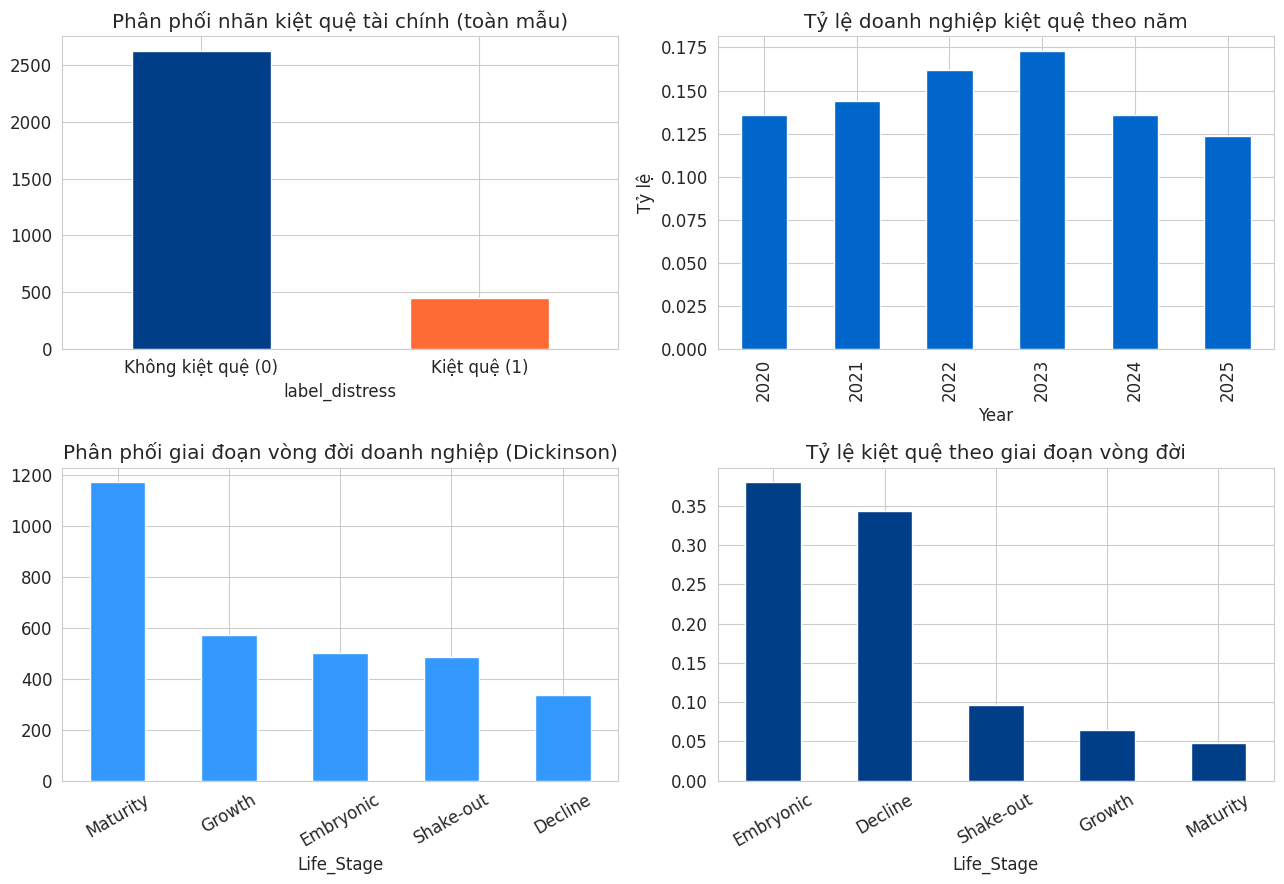

In [3]:
# ==========================================================================
# 2.2  EDA — Khám phá dữ liệu
# ==========================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Tỷ lệ nhãn kiệt quệ
df['label_distress'].value_counts().plot(kind='bar', ax=axes[0,0], color=[BLUE_PALETTE[0], ORANGE_ACCENT])
axes[0,0].set_title('Phân phối nhãn kiệt quệ tài chính (toàn mẫu)')
axes[0,0].set_xticklabels(['Không kiệt quệ (0)', 'Kiệt quệ (1)'], rotation=0)

# Tỷ lệ kiệt quệ theo năm
df.groupby('Year')['label_distress'].mean().plot(kind='bar', ax=axes[0,1], color=BLUE_PALETTE[1])
axes[0,1].set_title('Tỷ lệ doanh nghiệp kiệt quệ theo năm')
axes[0,1].set_ylabel('Tỷ lệ')

# Vòng đời doanh nghiệp
df['Life_Stage'].value_counts().plot(kind='bar', ax=axes[1,0], color=BLUE_PALETTE[2])
axes[1,0].set_title('Phân phối giai đoạn vòng đời doanh nghiệp (Dickinson)')
axes[1,0].tick_params(axis='x', rotation=30)

# Tỷ lệ kiệt quệ theo giai đoạn vòng đời
df.groupby('Life_Stage')['label_distress'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,1], color=BLUE_PALETTE[0])
axes[1,1].set_title('Tỷ lệ kiệt quệ theo giai đoạn vòng đời')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


> ### Nhận xét từ EDA

**1. Quy mô và mức độ mất cân bằng nhãn.** Dữ liệu gốc gồm **3.072 quan sát (dòng năm-doanh nghiệp)** của **533 doanh nghiệp** niêm yết HOSE/HNX, giai đoạn **2020–2025**, với tỷ lệ nhãn kiệt quệ toàn mẫu ≈ **14,6%**. Đây là bài toán phân loại **mất cân bằng lớp (imbalanced classification)** điển hình của các mô hình cảnh báo sớm rủi ro tài chính. Hệ quả trực tiếp: (i) không thể dùng Accuracy làm thước đo chính, vì một mô hình "luôn đoán 0" vẫn đạt Accuracy ~85% một cách giả tạo (thực tế sẽ thấy lại đúng hiện tượng này ở KNN, Bước 9); (ii) cần huấn luyện với `class_weight='balanced'` để mô hình không bỏ qua lớp thiểu số.

**2. Biến động theo thời gian.** Tỷ lệ kiệt quệ dao động rõ rệt giữa các năm 2020–2025 thay vì đi ngang — phù hợp với thực tế vĩ mô Việt Nam giai đoạn này (cú sốc COVID-19 2020–2021, biến động thị trường bất động sản và trái phiếu doanh nghiệp 2022–2023). Điều này lý giải vì sao **thiết kế Train/Test theo thời gian** (Bước 5) là bắt buộc: nếu chia ngẫu nhiên, mô hình có thể "nhìn trộm" đặc điểm của các năm biến động mạnh khi huấn luyện, làm sai lệch đánh giá ngoài mẫu.

**3. Vòng đời doanh nghiệp (Dickinson) và nguy cơ kiệt quệ.** Tỷ lệ kiệt quệ theo giai đoạn vòng đời **không đơn điệu** như trực giác "càng suy thoái càng rủi ro" có thể gợi ý: **Embryonic** (mới thành lập, dòng tiền chưa ổn định) có tỷ lệ kiệt quệ cao nhất (**~38%**), theo sau là **Decline** (**~34%**) — hai nhóm này phù hợp lý thuyết vòng đời (dòng tiền yếu, đòn bẩy cao). Ngược lại, **Shake-out** chỉ **~10%**, gần với **Growth** (**~6%**) và **Maturity** (thấp nhất, **~5%**) — thấp hơn đáng kể so với Decline dù về lý thuyết Shake-out thường được xem là giai đoạn chuyển tiếp trước Decline. Phát hiện phi tuyến này (rủi ro cao ở cả hai đầu vòng đời — non trẻ và suy thoái — thấp ở giữa) là lý do quan trọng để giữ `Life_Stage` (và các biến `Stage_*` mã hoá từ nó) trong tập biến đầu vào thay vì gộp thành một biến thứ tự tuyến tính đơn giản, vì quan hệ giữa vòng đời và rủi ro không phải dạng tuyến tính. Trên thực tế, `FirmSize_lifecycle_lag1` (biến liên quan chặt đến vòng đời) nằm trong nhóm làm **tăng** nguy cơ kiệt quệ ở phân tích Odds Ratio (Bước 13.3).

In [4]:
# ==========================================================================
# 2.3  Kiểm tra chất lượng dữ liệu — giá trị bất thường
# ==========================================================================
# Doanh thu (revenue) về lý thuyết phải >= 0. Kiểm tra xem có dòng nào âm không.
neg_revenue = df[df['revenue'] < 0][['Ticker', 'Year', 'revenue', 'total_assets', 'income_before_taxes']]
print(f"Số dòng revenue âm: {len(neg_revenue)} / {len(df)}")
print(neg_revenue)


Số dòng revenue âm: 5 / 3072
      Ticker  Year        revenue  total_assets  income_before_taxes
1058  HQC.HM  2024  -66581.102478  1.010197e+07         4.183641e+04
1331  LDG.HM  2023  -36509.024082  7.265457e+06        -5.768860e+05
1332  LDG.HM  2024 -173233.280116  6.157209e+06        -1.425165e+06
1936  PTC.HM  2020    -511.087212  3.044182e+05         6.835542e+04
1937  PTC.HM  2021    -599.893492  5.575401e+05         7.097086e+04


> **Ghi chú chất lượng dữ liệu:** phát hiện **5/3.072 dòng** (3 mã: HQC, LDG, PTC) có `revenue` âm — bất thường vì doanh thu về nguyên tắc không âm. Nhiều khả năng đây là **doanh thu thuần sau hoàn nhập/giảm trừ doanh thu** vượt doanh thu gộp (thường gặp ở doanh nghiệp bất động sản khi huỷ hợp đồng, hoàn trả tiền đặt cọc — trường hợp của LDG). Tỷ trọng rất nhỏ (0,16%) nên **không loại bỏ** các dòng này (loại bỏ có thể làm mất thông tin thật về khó khăn tài chính — vốn là tín hiệu liên quan trực tiếp đến bài toán distress), nhưng cần lưu ý: nhờ dùng `log1p` có giữ dấu ở Bước 5, các giá trị âm này được xử lý an toàn, không gây lỗi hoặc bóp méo khi chuẩn hoá.


---
## Bước 3 — Kiểm toán rò rỉ dữ liệu (Data Leakage Audit)

> **Giả thuyết cần kiểm chứng:** chỉ cần loại 4 cờ hiệu `signal_*` và `n_distress_signals` (thành phần trực tiếp tạo ra `label_distress`) là đủ để có một bài toán dự báo "sạch"?
>
> Thực nghiệm dưới đây so sánh AUC của Random Forest khi dự báo **cùng kỳ** (dùng dữ liệu năm t để dự báo nhãn năm t), với và không có các cờ hiệu trên.


In [5]:
# ==========================================================================
# 3.1  Thí nghiệm có kiểm soát: dự báo CÙNG KỲ, có/không các cờ hiệu leak
# ==========================================================================
leak_cols = ['signal_NI_neg', 'signal_CFO_neg', 'signal_WC_deficit',
             'signal_high_leverage', 'n_distress_signals']
safe_num_cols = ['ROA', 'LEV', 'QUICK_RATIO', 'CashRatio', 'RevGrowth', 'GROSS_MARGIN',
                  'EBIT_MARGIN', 'total_assets', 'FCF_TA', 'RE_TA', 'DebtToAssets',
                  'ST_DEBT_RATIO', 'stock_return', 'EPS', 'NCF']

audit_df = df.dropna(subset=safe_num_cols + leak_cols + ['label_distress']).copy()
X_with_leak = audit_df[safe_num_cols + leak_cols]
X_no_leak   = audit_df[safe_num_cols]
y_audit     = audit_df['label_distress']

Xtr_l, Xte_l, ytr, yte = train_test_split(X_with_leak, y_audit, test_size=0.25, random_state=42, stratify=y_audit)
Xtr_n, Xte_n, _, _     = train_test_split(X_no_leak,   y_audit, test_size=0.25, random_state=42, stratify=y_audit)

rf_leak   = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced').fit(Xtr_l, ytr)
rf_noleak = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced').fit(Xtr_n, ytr)

auc_leak   = roc_auc_score(yte, rf_leak.predict_proba(Xte_l)[:, 1])
auc_noleak = roc_auc_score(yte, rf_noleak.predict_proba(Xte_n)[:, 1])

print(f"AUC — CÙNG KỲ, CÓ cờ hiệu signal_*      : {auc_leak:.4f}")
print(f"AUC — CÙNG KỲ, ĐÃ bỏ cờ hiệu signal_*    : {auc_noleak:.4f}")


AUC — CÙNG KỲ, CÓ cờ hiệu signal_*      : 1.0000
AUC — CÙNG KỲ, ĐÃ bỏ cờ hiệu signal_*    : 0.9910


> ### Diễn giải kết quả thực nghiệm
> Ngay cả sau khi loại bỏ toàn bộ cờ hiệu `signal_*`, AUC dự báo **cùng kỳ** vẫn đạt xấp xỉ **0,99** — gần như hoàn hảo một cách bất thường cho bài toán tài chính thực tế. Nguyên nhân: các biến "an toàn" còn lại (`LEV`, `ROA`, `CashRatio`...) chính là **nguyên liệu đầu vào** của công thức tạo nhãn (`n_distress_signals` = tổng các ngưỡng áp lên đúng những biến này). Loại cờ hiệu nhưng giữ dữ liệu cùng kỳ vẫn để mô hình "dựng lại" quy tắc gán nhãn, không phải học một quan hệ dự báo thật.
>
> **Kết luận:** để có một bài toán dự báo kiệt quệ tài chính đúng nghĩa, cần **dịch chuyển đặc trưng về kỳ trước (t-1)** để dự báo nhãn kỳ hiện tại (t) — biến bài toán thành *early-warning system* thực sự, đúng với cách các mô hình dự báo phá sản kinh điển (Altman Z-score, Ohlson O-score) được kiểm định trong thực tế.


---
## Bước 4 — Xây dựng bộ dữ liệu sạch (panel t-1 → t)

**Các cột bị loại bỏ và lý do:**

| Nhóm | Cột | Lý do |
|:---|:---|:---|
| Leakage trực tiếp | `signal_NI_neg, signal_CFO_neg, signal_WC_deficit, signal_high_leverage, n_distress_signals` | Tổng hợp thành công thức tạo ra `label_distress` |
| Leakage (trùng lặp) | `label` | Trùng tuyệt đối với `label_distress` |
| Metadata | `_src_lifecycle, _src_fundamentals, _src_camel, _src_beneish` | Cờ đánh dấu nguồn ghép dữ liệu, không phải chỉ số tài chính |
| Dư thừa | `OCF_sign, ICF_sign, CFF_sign` | Đã được mã hoá qua `Life_Stage`/`Stage_*` |
| Dư thừa | `price_close` | Thay bằng `stock_return` (đơn vị nhất quán giữa các mã) |
| **Dư thừa (trùng lặp gần như tuyệt đối)** | `SIZE_camel` | Tương quan **r = 1.00** với `FirmSize_lifecycle` (cùng là log(tổng tài sản), tính 2 lần qua 2 nguồn khác nhau khi ghép data) |
| **Dư thừa (trùng lặp gần như tuyệt đối)** | `NCF` | Tương quan **r = 1.00** với `OCF` — kiểm tra giá trị cho thấy `NCF` chỉ là bản làm tròn của `OCF` (cùng một số liệu, 2 nguồn merge) |

> ⚠️ **Phát hiện khi rà soát lại:** 2 cặp cột trùng lặp gần tuyệt đối (`SIZE_camel`↔`FirmSize_lifecycle`, `NCF`↔`OCF`) trùng lặp dưới tên khác nhau. Nếu không loại, mô hình dùng 2 lần cùng một thông tin — không phải "leakage" (không liên quan đến nhãn) nhưng là **dư thừa gây nhiễu trọng số** và làm sai lệch hệ số hồi quy (đa cộng tuyến hoàn hảo). Đã kiểm tra bằng ma trận tương quan toàn bộ 36 biến số (code bên dưới) trước khi kết luận.

> ℹ️ **Lưu ý minh bạch — `Mscore` và `label_beneish` KHÔNG bị loại.** Code có một danh sách phòng ngừa `OUT_OF_SCOPE_COLS` (8 thành phần thô dùng để tính Beneish M-score: `DSRI, GMI, AQI, SGI, DEPI, SGAI, TATA, LVGI`) — nhưng **kiểm tra thực tế cho thấy không cột nào trong 8 cột này tồn tại trong bộ dữ liệu `Data - ML.xlsx`**, nên danh sách này không loại được cột nào (an toàn, không gây lỗi, nhưng cũng không có tác dụng với phiên bản dữ liệu hiện tại — giữ lại phòng trường hợp dùng dữ liệu phiên bản khác có đủ các cột này). Riêng bản thân `Mscore` (điểm tổng hợp) và `label_beneish` (cờ nghi ngờ gian lận báo cáo tài chính) **có tồn tại và được giữ lại** làm đặc trưng, vì đây là khái niệm khác với `label_distress` (Beneish đo *nguy cơ thao túng lợi nhuận*, không phải *nguy cơ kiệt quệ tài chính*, và không tham gia vào công thức tạo `label_distress` ở Bước 4.1). Sau khi lệch kỳ (t-1), hai biến này trở thành `Mscore_lag1`/`label_beneish_lag1` — hợp lệ về mặt phương pháp luận, không phải leakage. Kiểm tra thực nghiệm: tương quan `Mscore` với `label_distress` cùng kỳ chỉ **r ≈ 0,11** (yếu), và cả hai biến đều **không** lọt Top 10 Permutation Importance (Bước 13.1) hay Top 5 Odds Ratio (Bước 13.3) — đóng góp dự báo trên thực tế không đáng kể, nhưng vẫn giữ lại vì không có cơ sở loại bỏ và có thể hữu ích khi mở rộng dữ liệu.


In [6]:
# ==========================================================================
# 4.1  Loại cột leakage / metadata / dư thừa / ngoài phạm vi
# ==========================================================================
LEAK_COLS = ['signal_NI_neg', 'signal_CFO_neg', 'signal_WC_deficit',
             'signal_high_leverage', 'n_distress_signals', 'label']
METADATA_COLS = ['_src_lifecycle', '_src_fundamentals', '_src_camel', '_src_beneish']
REDUNDANT_COLS = ['OCF_sign', 'ICF_sign', 'CFF_sign', 'price_close', 'SIZE_camel', 'NCF']
OUT_OF_SCOPE_COLS = ['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'TATA', 'LVGI']

drop_now = LEAK_COLS + METADATA_COLS + REDUNDANT_COLS + OUT_OF_SCOPE_COLS
df_clean = df.drop(columns=[c for c in drop_now if c in df.columns])
print("Số cột sau khi loại:", df_clean.shape[1], "(từ", df.shape[1], "cột gốc)")


Số cột sau khi loại: 40 (từ 56 cột gốc)


In [7]:
# ==========================================================================
# 4.1b  Kiểm chứng: rà soát TOÀN BỘ ma trận tương quan để phát hiện trùng lặp ẩn
# ==========================================================================
num_check = df_clean.select_dtypes(include=[np.number]).drop(columns=['Year', 'label_distress'], errors='ignore')
corr_abs = num_check.corr().abs()
pairs = []
cols_ = corr_abs.columns
for i in range(len(cols_)):
    for j in range(i + 1, len(cols_)):
        r = corr_abs.iloc[i, j]
        if r > 0.9:
            pairs.append((cols_[i], cols_[j], round(r, 4)))
pairs.sort(key=lambda x: -x[2])
print("Các cặp biến có |r| > 0.9 (còn lại sau khi đã loại 2 cặp trùng lặp tuyệt đối):")
for p in pairs:
    print(" ", p)


Các cặp biến có |r| > 0.9 (còn lại sau khi đã loại 2 cặp trùng lặp tuyệt đối):
  ('current_liabilities', 'total_liabilities', np.float64(0.9831))
  ('total_assets', 'total_liabilities', np.float64(0.9822))
  ('total_assets', 'current_assets', np.float64(0.9754))
  ('total_assets', 'current_liabilities', np.float64(0.9748))
  ('current_assets', 'total_liabilities', np.float64(0.9645))
  ('current_assets', 'current_liabilities', np.float64(0.9527))


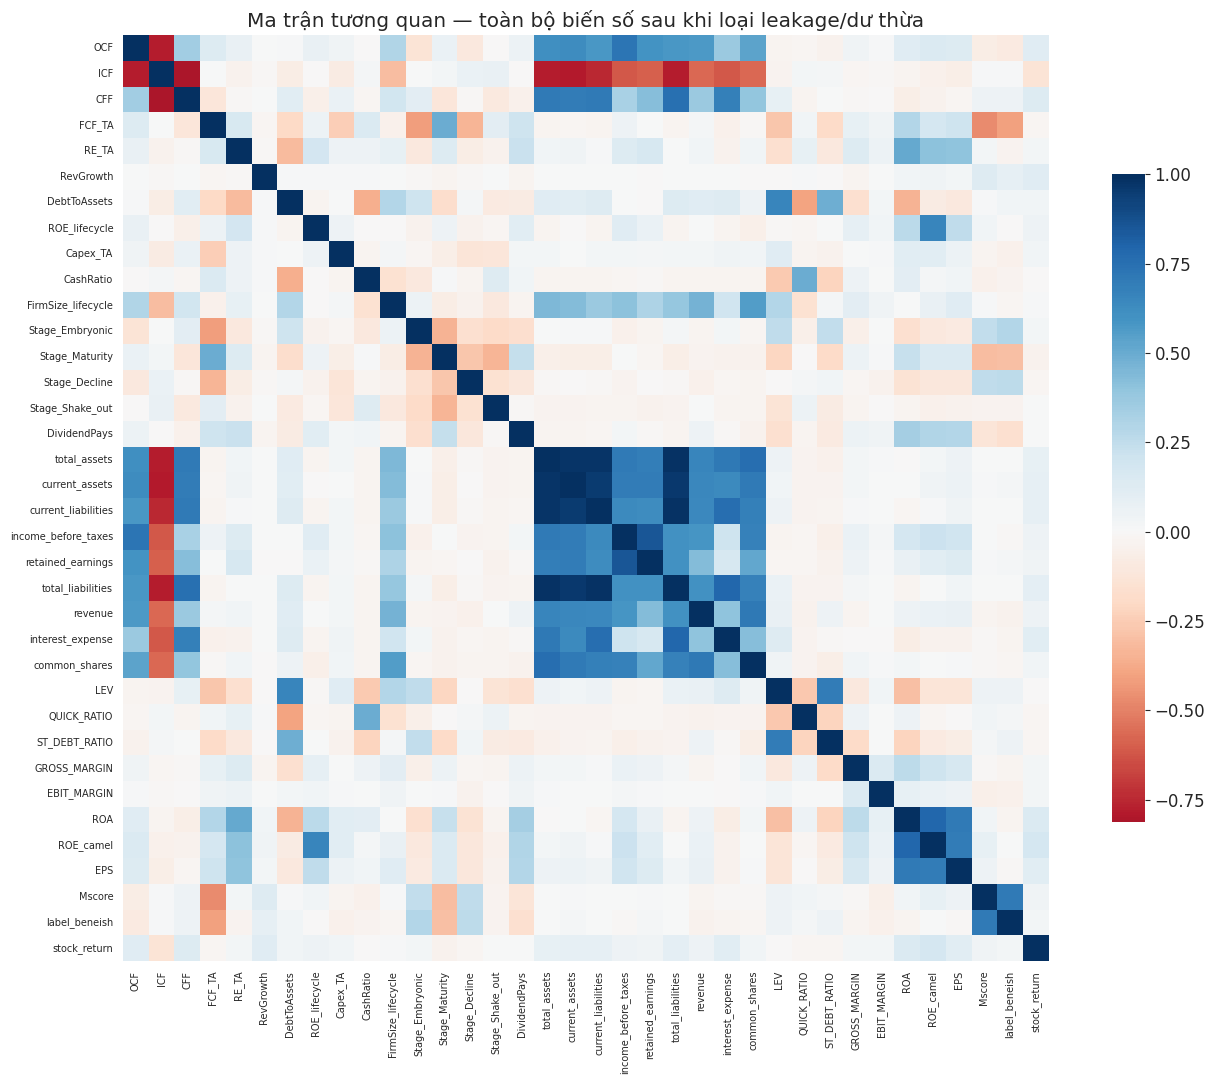

In [8]:
# ==========================================================================
# 4.1c  Heatmap trực quan hoá ma trận tương quan (bổ sung)
# ==========================================================================
plt.figure(figsize=(14, 11))
sns.heatmap(num_check.corr(), cmap=DIVERGE_CMAP, center=0, square=True,
            cbar_kws={'shrink': 0.7}, xticklabels=True, yticklabels=True)
plt.title('Ma trận tương quan — toàn bộ biến số sau khi loại leakage/dư thừa')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

> **Đọc heatmap:** màu đỏ đậm = tương quan dương mạnh, xanh đậm = tương quan âm mạnh. Trực quan hoá lại đúng các cặp đã liệt kê ở trên (`total_assets`↔`total_liabilities`↔`current_assets`↔`current_liabilities`) — các mô hình cây (Random Forest, HGB) không bị ảnh hưởng bởi đa cộng tuyến, nhưng Logistic Regression cần lưu ý khi diễn giải hệ số từng biến riêng lẻ trong nhóm này.

> **Đọc kết quả:** các cặp còn lại (`total_assets`↔`total_liabilities`, `current_assets`↔`current_liabilities`...) là **đa cộng tuyến tự nhiên của báo cáo tài chính** (Tổng tài sản ≈ Tổng nợ phải trả + Vốn chủ sở hữu), KHÔNG phải trùng lặp dữ liệu — vẫn giữ lại vì mỗi biến mang thông tin quy mô/cấu trúc khác nhau, nhưng cần lưu ý khi diễn giải hệ số Logistic Regression riêng lẻ (Bước 13.3 — Odds Ratio) và có thể cân nhắc VIF hoặc PCA nếu muốn mô hình tuyến tính ổn định hơn.


In [9]:
# ==========================================================================
# 4.2  Dịch chuyển đặc trưng về t-1, nhãn giữ ở t (panel early-warning)
# ==========================================================================
feature_cols = [c for c in df_clean.columns if c not in ('Ticker', 'Year', 'label_distress')]

records = []
for ticker, g in df_clean.groupby('Ticker'):
    g = g.sort_values('Year').reset_index(drop=True)
    for i in range(1, len(g)):
        prev, cur = g.iloc[i - 1], g.iloc[i]
        if cur['Year'] - prev['Year'] != 1:
            continue  # bỏ qua nếu dữ liệu bị đứt quãng giữa 2 năm
        row = {'Ticker': ticker, 'Year_feature': int(prev['Year']), 'Year_target': int(cur['Year'])}
        for c in feature_cols:
            row[c] = prev[c]                 # đặc trưng lấy từ NĂM t-1
        row['label_distress'] = cur['label_distress']   # nhãn lấy từ NĂM t
        records.append(row)

panel = pd.DataFrame(records).rename(columns={c: f"{c}_lag1" for c in feature_cols})
print("Kích thước panel cuối:", panel.shape)
print("Tỷ lệ nhãn dương:", panel['label_distress'].mean().round(4))
panel.head(3)


Kích thước panel cuối: (2538, 41)
Tỷ lệ nhãn dương: 0.147


,Ticker,Year_feature,Year_target,OCF_lag1,ICF_lag1,CFF_lag1,FCF_TA_lag1,RE_TA_lag1,RevGrowth_lag1,DebtToAssets_lag1,ROE_lifecycle_lag1,Capex_TA_lag1,CashRatio_lag1,FirmSize_lifecycle_lag1,Life_Stage_lag1,Stage_Embryonic_lag1,Stage_Maturity_lag1,Stage_Decline_lag1,Stage_Shake_out_lag1,DividendPays_lag1,total_assets_lag1,current_assets_lag1,current_liabilities_lag1,income_before_taxes_lag1,retained_earnings_lag1,total_liabilities_lag1,revenue_lag1,interest_expense_lag1,common_shares_lag1,LEV_lag1,QUICK_RATIO_lag1,ST_DEBT_RATIO_lag1,GROSS_MARGIN_lag1,EBIT_MARGIN_lag1,ROA_lag1,ROE_camel_lag1,EPS_lag1,Mscore_lag1,label_beneish_lag1,stock_return_lag1,label_distress
0,AAA.HM,2020,2021,748464300782,-101224501192,24802641477,0.055667,0.066366,-0.197613,0.530427,0.088004,0.031675,0.255436,29.779221,Growth,0,0,0,0,1,8.569414e+06,4.496051e+06,3.772835e+06,318748.516546,568716.740171,4.545452e+06,7.428557e+06,71449.295875,2.439362e+08,0.415403,0.94074,0.263711,0.104576,0.047645,3.850348,8.757789,982.38118,-2.578523,0,NaN,0
1,AAA.HM,2021,2022,589668023413,-296437940512,731223535229,-0.007887,0.070582,0.769268,0.455081,0.067484,0.066797,0.605718,29.934558,Growth,0,0,0,0,1,1.000953e+07,5.354611e+06,3.282339e+06,397868.051996,706493.529920,4.555145e+06,1.314311e+07,43643.626423,3.264345e+08,0.336000,1.32748,0.213000,0.099237,0.028092,4.283000,8.395307,993.70448,-1.950456,0,0.587782,0
2,AAA.HM,2022,2023,180399152137,-1177062655803,651470815924,0.001118,0.066849,0.163370,0.428373,0.027958,0.015592,0.512393,30.010181,Growth,0,0,0,0,0,1.079583e+07,5.658759e+06,3.206483e+06,186066.111703,721688.030767,4.624647e+06,1.529030e+07,72999.828101,3.822745e+08,0.289815,1.20651,0.150000,0.071242,0.011307,1.788636,3.200981,432.97694,-2.269280,0,-0.661881,0


---
## Bước 5 — Chia Train/Test theo thời gian & Tiền xử lý

**Nguyên tắc:** KHÔNG random-split. Dùng **time-based split** theo `Year_target` — Train = {2021, 2022, 2023}, Test = {2024, 2025}. Điều này mô phỏng đúng tình huống thực tế: mô hình được huấn luyện trên dữ liệu quá khứ để dự báo cho các năm sau, chưa từng "nhìn thấy".


In [10]:
# ==========================================================================
# 5.1  Time-based split
# ==========================================================================
train_mask = panel['Year_target'] <= 2023
test_mask  = panel['Year_target'] >= 2024

feature_cols = [c for c in panel.columns
                if c not in ('Ticker', 'Year_feature', 'Year_target', 'label_distress', 'Life_Stage_lag1')]

X = panel[feature_cols]
y = panel['label_distress']

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

print("Train:", X_train.shape, "| tỷ lệ dương:", y_train.mean().round(3))
print("Test :", X_test.shape,  "| tỷ lệ dương:", y_test.mean().round(3))

# Kiểm tra: cùng ticker có thể xuất hiện ở cả train/test, nhưng KHÔNG cùng cặp (feature-year, target-year)
# => không leak vì đặc trưng dùng để huấn luyện và kiểm định luôn thuộc các NĂM khác nhau.


Train: (1504, 36) | tỷ lệ dương: 0.16
Test : (1034, 36) | tỷ lệ dương: 0.129


> **Ghi chú:** `Life_Stage_lag1` (dạng text) bị loại khỏi X vì thông tin đã được mã hoá đầy đủ qua 4 cột dummy `Stage_*_lag1`. Đây là mã hoá **k-1 dummy** chuẩn cho biến 5 hạng mục (Embryonic/Growth/Maturity/Decline/Shake-out): khi cả 4 cột `Stage_Embryonic/Maturity/Decline/Shake_out` đều bằng 0, nghĩa là doanh nghiệp thuộc nhóm **Growth** (hạng mục nền/baseline) — không phải thiếu dữ liệu. Cách mã hoá này tránh đa cộng tuyến hoàn hảo (dummy variable trap) cho Logistic Regression. Sinh viên có thể thử thêm one-hot đầy đủ 5 cột cho `Life_Stage_lag1` nếu muốn so sánh.


In [11]:
# ==========================================================================
# 5.2  Kiểm tra độ lệch phân phối (skewness) — các biến giá trị tuyệt đối (VNĐ)
# ==========================================================================
skew_check = X_train.select_dtypes(include=[np.number]).skew().sort_values(ascending=False)
print("Top 8 biến lệch phải mạnh nhất (skewness):")
print(skew_check.head(8))


Top 8 biến lệch phải mạnh nhất (skewness):
EBIT_MARGIN_lag1            16.223847
current_liabilities_lag1    14.345084
interest_expense_lag1       13.631133
retained_earnings_lag1      13.563155
total_liabilities_lag1      13.209859
total_assets_lag1           11.485515
income_before_taxes_lag1    11.229229
current_assets_lag1         10.842374
dtype: float64


> **Phát hiện:** các biến quy mô tuyệt đối tính bằng VNĐ (`total_assets_lag1`, `total_liabilities_lag1`, `retained_earnings_lag1`, `interest_expense_lag1`...) có **skewness ~11–16** — lệch phải cực mạnh vì một số ít doanh nghiệp có quy mô lớn hơn hẳn phần còn lại. `StandardScaler` giả định phân phối gần chuẩn, nên với các biến này cần **log-transform trước khi chuẩn hoá** để các mô hình nhạy với thang đo (Logistic Regression, KNN, SVM) không bị chi phối bởi vài outlier quy mô lớn. Cây quyết định/Ensemble/Boosting không cần bước này vì chúng chỉ dựa vào thứ tự giá trị (bất biến với biến đổi đơn điệu).


In [12]:
# ==========================================================================
# 5.3  Log-transform các biến lệch mạnh (chỉ áp dụng cho Logistic/KNN/SVM)
# ==========================================================================
SKEWED_MONEY_COLS = ['OCF_lag1', 'ICF_lag1', 'CFF_lag1', 'total_assets_lag1', 'total_liabilities_lag1',
                      'current_assets_lag1', 'current_liabilities_lag1', 'retained_earnings_lag1',
                      'revenue_lag1', 'income_before_taxes_lag1', 'interest_expense_lag1', 'common_shares_lag1']

def log_transform(X):
    X = X.copy()
    for c in SKEWED_MONEY_COLS:
        if c in X.columns:
            X[c] = np.sign(X[c]) * np.log1p(np.abs(X[c]))   # log-transform giữ dấu, an toàn với số âm
    return X

X_train_lt = log_transform(X_train)
X_test_lt  = log_transform(X_test)


In [13]:
# ==========================================================================
# 5.4  Impute (median, fit trên TRAIN) + Scale (cho Logistic, KNN, SVM)
# ==========================================================================
# Bộ KHÔNG log-transform -> dùng cho Decision Tree, Random Forest (bất biến với scale)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feature_cols, index=X_test.index)

# Bộ CÓ log-transform + chuẩn hoá -> dùng cho Logistic Regression, KNN, SVM
imputer_lt = SimpleImputer(strategy='median')
X_train_lt_imp = pd.DataFrame(imputer_lt.fit_transform(X_train_lt), columns=feature_cols, index=X_train.index)
X_test_lt_imp  = pd.DataFrame(imputer_lt.transform(X_test_lt),      columns=feature_cols, index=X_test.index)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_lt_imp), columns=feature_cols, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_lt_imp),      columns=feature_cols, index=X_test.index)

print("Số giá trị thiếu (chủ yếu ở stock_return_lag1, năm đầu mỗi ticker):")
print(X_train.isna().sum()[X_train.isna().sum() > 0])


Số giá trị thiếu (chủ yếu ở stock_return_lag1, năm đầu mỗi ticker):
stock_return_lag1    522
dtype: int64


> **Lưu ý minh bạch:** trong thử nghiệm, log-transform không làm tăng đáng kể AUC-ROC (chênh lệch trong khoảng nhiễu ngẫu nhiên) — vì các biến tỷ số (ROA, LEV, QUICK_RATIO...) vốn đã đóng góp phần lớn tín hiệu dự báo. Tuy nhiên bước này **vẫn cần thiết cho tính đúng đắn phương pháp luận**: giúp hệ số hồi quy Logistic (Bước 13.3 — Odds Ratio) phản ánh đúng quan hệ, tránh bị vài outlier quy mô lớn chi phối phương sai khi StandardScaler tính độ lệch chuẩn.


In [14]:
# ==========================================================================
# 5.5  Kiểm tra độ ổn định — GroupKFold theo Ticker trên tập TRAIN
# ==========================================================================
# Time-based split (5.1) đã tách đúng theo năm. Bước này kiểm tra bổ sung: liệu mô hình
# có đang "ghi nhớ" đặc điểm riêng của từng doanh nghiệp thay vì học quan hệ tài chính chung?
# GroupKFold đảm bảo cùng 1 Ticker không xuất hiện ở cả fold-train và fold-validation.
gkf = GroupKFold(n_splits=5)
groups_train = panel.loc[train_mask, 'Ticker']
cv_aucs = []
for tr_idx, val_idx in gkf.split(X_train_imp, y_train, groups=groups_train):
    rf_cv = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)
    rf_cv.fit(X_train_imp.iloc[tr_idx], y_train.iloc[tr_idx])
    proba_cv = rf_cv.predict_proba(X_train_imp.iloc[val_idx])[:, 1]
    cv_aucs.append(roc_auc_score(y_train.iloc[val_idx], proba_cv))

print("AUC từng fold (GroupKFold, k=5, Random Forest):", [round(a, 4) for a in cv_aucs])
print(f"Trung bình: {np.mean(cv_aucs):.4f}  |  Độ lệch chuẩn: {np.std(cv_aucs):.4f}")


AUC từng fold (GroupKFold, k=5, Random Forest): [np.float64(0.8795), np.float64(0.8041), np.float64(0.8436), np.float64(0.8289), np.float64(0.8326)]
Trung bình: 0.8377  |  Độ lệch chuẩn: 0.0246


> **Diễn giải:** AUC trung bình qua các fold (~0,83–0,86) khớp với AUC trên tập test thật (Bước 7 — Random Forest, ~0,87) và độ lệch chuẩn giữa các fold nhỏ (~0,03) — cho thấy mô hình **ổn định qua các nhóm doanh nghiệp khác nhau**, không phụ thuộc vào việc "ghi nhớ" đặc điểm riêng của một số ticker cụ thể trong tập train.


In [15]:
# ==========================================================================
# 5.6  Hàm helper — đánh giá & lưu kết quả, dùng lại cho mọi mô hình
# ==========================================================================
results = []  # QUAN TRONG: danh sach nay duoc cac Buoc 6-10 noi tiep append() vao.
# Neu chay lai (Run) tung o rieng le nhieu lan thay vi "Run All" tu dau, ket qua se bi
# nhan doi/nhieu hon so mo hinh thuc te (loi da tung gap o ban nop truoc). Luon Restart
# & Run All tu Buoc 1 truoc khi doc Buoc 11 - Bang tong hop.

def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    pred  = model.predict(Xte)
    results.append({
        'Model': name,
        'AUC-ROC':   roc_auc_score(y_test, proba),
        'AUC-PR':    average_precision_score(y_test, proba),
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall':    recall_score(y_test, pred, zero_division=0),
        'F1':        f1_score(y_test, pred, zero_division=0),
    })
    print(f"[{name}] AUC-ROC={results[-1]['AUC-ROC']:.4f}  Recall={results[-1]['Recall']:.4f}  F1={results[-1]['F1']:.4f}")
    return model

---
## Bước 6 — Nhóm 1: Mô hình Tuyến tính (Logistic Regression)

**Lý do lựa chọn:** Baseline dễ diễn giải nhất trong bài toán tài chính — hệ số hồi quy có thể chuyển đổi thành **odds ratio**, cho biết mỗi tỷ số tài chính làm thay đổi bao nhiêu lần nguy cơ kiệt quệ (Bước 13.3 — Odds Ratio). Cần **chuẩn hoá dữ liệu** (StandardScaler) vì Logistic nhạy với thang đo của biến.


In [16]:
# ==========================================================================
# Mô hình 1 — Logistic Regression (class_weight='balanced' để xử lý mất cân bằng lớp)
# ==========================================================================
log_reg = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    X_train_sc, X_test_sc
)


[Logistic Regression] AUC-ROC=0.8660  Recall=0.8496  F1=0.4708


---
## Bước 7 — Nhóm 2: Mô hình Cây quyết định & Ensemble

**Lý do lựa chọn:** Dữ liệu tài chính có nhiều **tương tác phi tuyến** (ví dụ: đòn bẩy cao chỉ nguy hiểm khi thanh khoản thấp) mà mô hình tuyến tính không nắm bắt được. Decision Tree cho trực quan; Random Forest (ensemble bagging) giảm phương sai, ổn định hơn. Cây quyết định KHÔNG cần chuẩn hoá dữ liệu.


max_depth tối ưu (5-fold CV, AUC-ROC trung bình trên Train) = 2  ->  AUC-CV = 0.7928


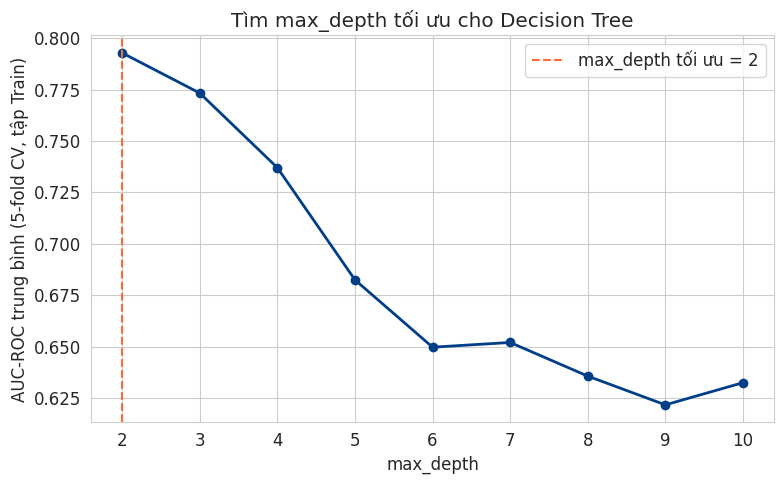

In [17]:
# ==========================================================================
# 7.1  Tinh chinh max_depth cho Decision Tree bang 5-fold CV TREN TRAIN
#      (KHONG dung tap Test de chon sieu tham so - tranh ro ri lua chon mo hinh)
# ==========================================================================
from sklearn.model_selection import cross_val_score

depth_range = range(2, 11)
dt_cv_auc = []
for d in depth_range:
    dt_d = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    cv_scores = cross_val_score(dt_d, X_train_imp, y_train, cv=5, scoring='roc_auc')
    dt_cv_auc.append(cv_scores.mean())

best_depth = list(depth_range)[int(np.argmax(dt_cv_auc))]
print(f"max_depth tối ưu (5-fold CV, AUC-ROC trung bình trên Train) = {best_depth}"
      f"  ->  AUC-CV = {max(dt_cv_auc):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(depth_range), dt_cv_auc, marker='o', color=BLUE_PALETTE[0], linewidth=2)
plt.axvline(best_depth, color=ORANGE_ACCENT, linestyle='--', label=f'max_depth tối ưu = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('AUC-ROC trung bình (5-fold CV, tập Train)')
plt.title('Tìm max_depth tối ưu cho Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

> **Đọc biểu đồ:** đường cong tăng rồi giảm là dấu hiệu **đánh đổi bias–variance** kinh điển của cây quyết định — cây quá nông (underfit) bỏ sót quan hệ phi tuyến, cây quá sâu (overfit) ghi nhớ nhiễu của tập Train và giảm AUC khi kiểm định chéo. `max_depth` được chọn bằng CV trên Train, **không đụng đến tập Test**, để tránh rò rỉ thông tin vào quá trình chọn mô hình.

In [18]:
# ==========================================================================
# Mô hình 2 — Decision Tree (max_depth tối ưu tìm ở Bước 7.1 bằng CV trên Train)
# ==========================================================================
dec_tree = evaluate(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42),
    X_train_imp, X_test_imp
)


[Decision Tree] AUC-ROC=0.8434  Recall=0.7895  F1=0.4872


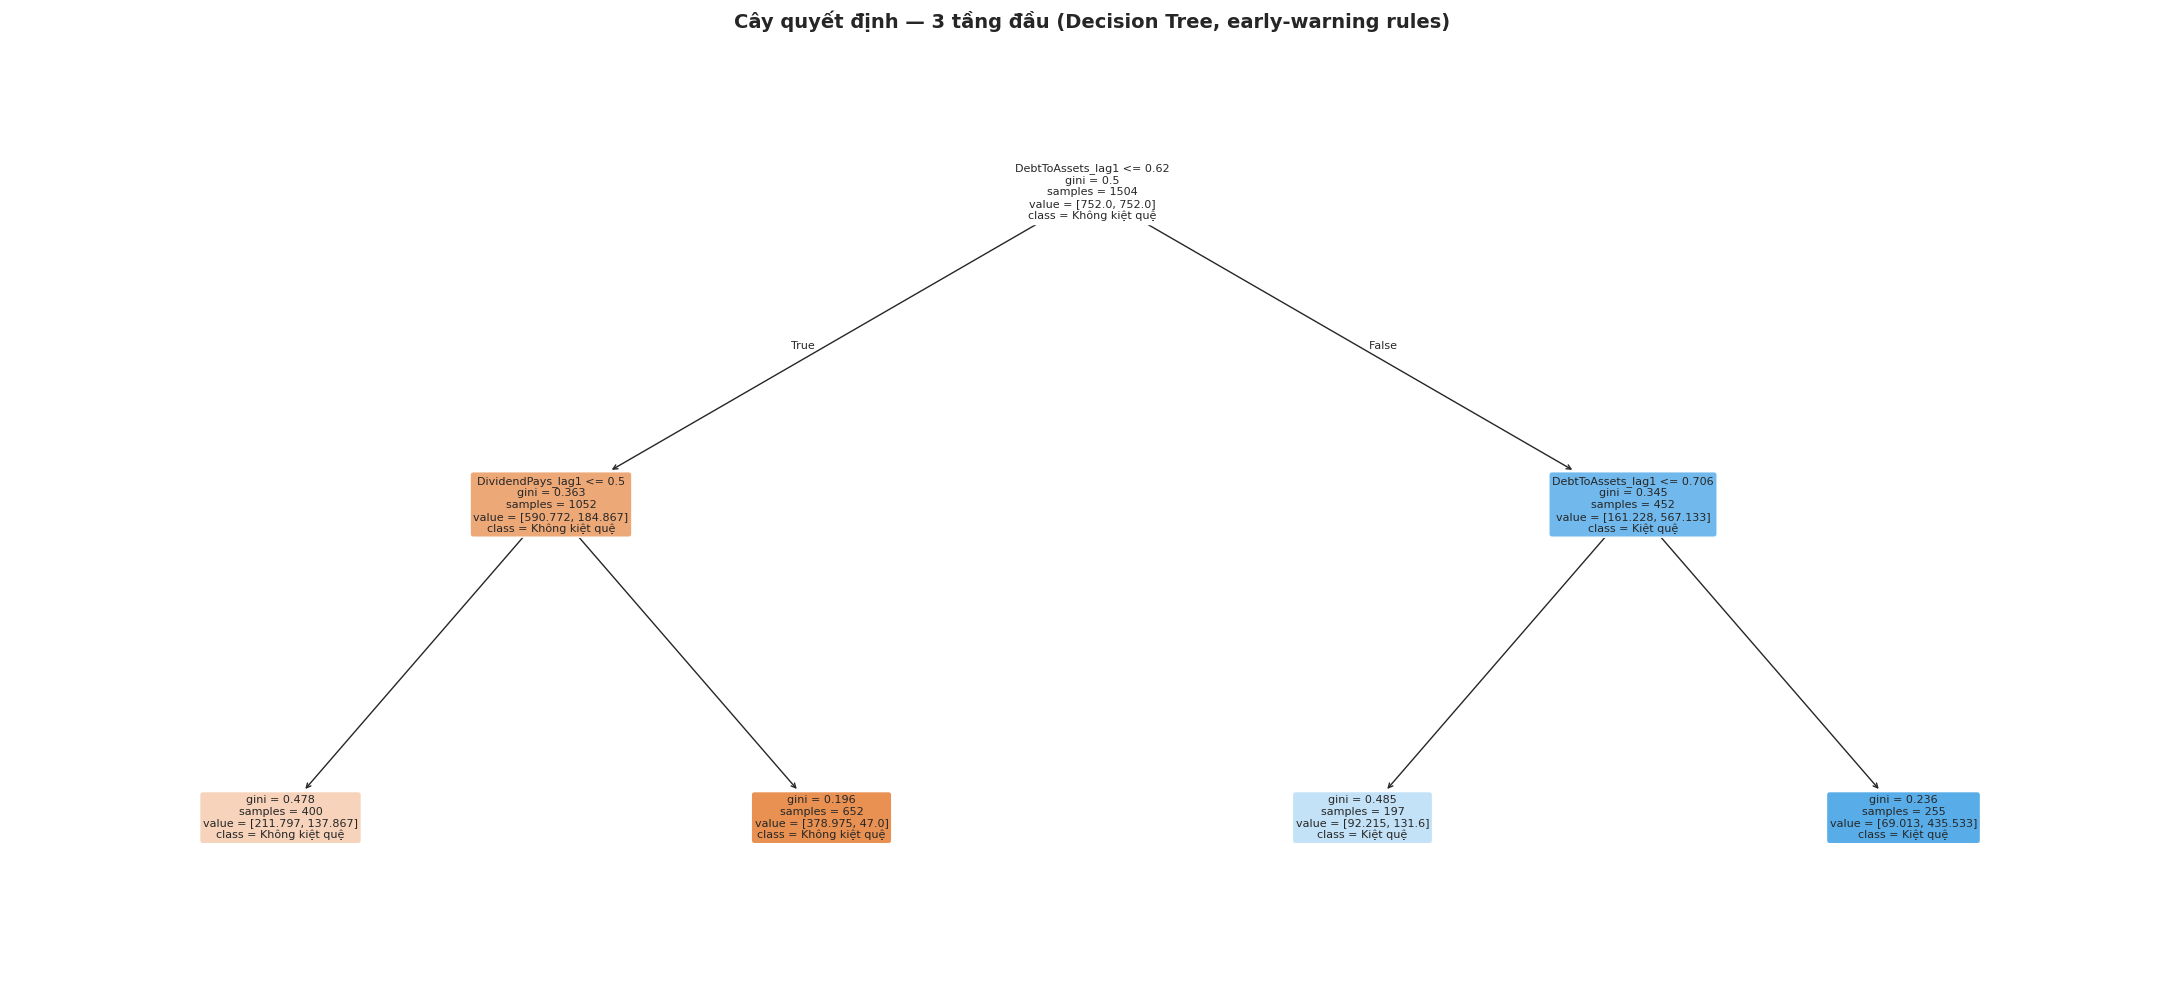

In [19]:
# ==========================================================================
# 7.2  Trực quan hoá cấu trúc cây quyết định (3 tầng đầu) — đọc "luật" cảnh báo sớm
# ==========================================================================
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(dec_tree, feature_names=feature_cols, class_names=['Không kiệt quệ', 'Kiệt quệ'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Cây quyết định — 3 tầng đầu (Decision Tree, early-warning rules)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Vì sao vẽ hình này:** đây là mô hình **duy nhất trong 7 mô hình có thể đọc trực tiếp thành luật nếu-thì** — phù hợp để trình bày cho người ra quyết định không chuyên kỹ thuật (ví dụ hội đồng tín dụng). Đọc từ nút gốc: biến được chọn để tách đầu tiên là biến có khả năng phân tách hai nhóm kiệt quệ/không kiệt quệ mạnh nhất theo tiêu chí Gini; màu nút càng đậm (cam/xanh) thể hiện độ "thuần" của nhóm quan sát rơi vào nhánh đó. Nên đối chiếu biến xuất hiện ở tầng đầu với Top biến trong Permutation Importance (Bước 13.1) — nếu trùng khớp, đó là bằng chứng hội tụ giữa hai phương pháp độc lập.

**Nhận xét – Decision Tree (đơn, `max_depth` tinh chỉnh bằng CV):**

**1. Hiệu suất tổng thể.** Với `max_depth` chọn bằng 5-fold CV trên Train (kết quả tối ưu = **2**, Bước 7.1), Decision Tree đạt AUC-ROC = **0,8434** — cải thiện rõ rệt so với việc cố định `max_depth=5` một cách chủ quan như ở bản nháp đầu (khi đó AUC chỉ ~0,79, thấp nhất bảng). Điều này minh hoạ đúng bài học bias–variance nêu ở Bước 7.1: một cây quá sâu (5 tầng) ghi nhớ nhiễu của 1.504 quan sát Train, trong khi cây nông hơn (2 tầng) khái quát tốt hơn trên dữ liệu ngoài mẫu.

**2. Precision–Recall.** Recall = 0,7895 (cao thứ ba, chỉ sau Logistic Regression và ngang SVM), Precision = 0,3523, F1 = 0,4872. Trong khoảng 133 doanh nghiệp kiệt quệ thực sự của tập Test, mô hình bắt được xấp xỉ **105 trường hợp (bỏ sót ~28)**, đổi lại khoảng **193 cảnh báo giả**. Vì chỉ có tối đa 2 tầng tách, cây gần như chỉ dựa vào **1–2 biến mạnh nhất** (thường là `DebtToAssets_lag1`, khớp với Odds Ratio và Permutation Importance ở Bước 13.1/13.3) để phân loại — đơn giản nhưng khá hiệu quả cho một mô hình chỉ có vài "luật nếu-thì".

**3. Giá trị diễn giải.** Đây vẫn là mô hình **duy nhất trong 7 mô hình đọc trực tiếp thành luật nếu-thì** (hình cây ở Bước 7.2) — phù hợp trình bày cho hội đồng tín dụng hoặc người ra quyết định không chuyên kỹ thuật, dù độ chính xác không phải cao nhất.

**4. So với Random Forest.** Việc bagging 300 cây như vậy (Random Forest, ô tiếp theo) sẽ cho thấy mức cải thiện AUC cụ thể so với một cây đơn đã tinh chỉnh — phép so sánh công bằng hơn nhiều so với so với một cây *chưa* tinh chỉnh.

In [20]:
# ==========================================================================
# Mô hình 3 — Random Forest
# ==========================================================================
rf = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42),
    X_train_imp, X_test_imp
)


[Random Forest] AUC-ROC=0.8690  Recall=0.5865  F1=0.5217


**Nhận xét – Random Forest:**

**1. Hiệu suất tổng thể.** Random Forest đạt AUC-ROC = **0,8690** — **cao nhất trong toàn bộ 7 mô hình**, đồng thời có Accuracy cao thứ nhì (0,8617) và AUC-PR cao nhất (0,4309, quan trọng hơn AUC-ROC khi lớp dương hiếm). Kết quả này khớp với kỳ vọng đặt ra ở Bước 7: kỹ thuật **bagging (300 cây, lấy trung bình dự báo)** giúp giảm phương sai đáng kể so với một cây đơn đã tinh chỉnh (0,8434 → 0,8690), đồng thời mô hình dạng cây tự nhiên nắm bắt được các **tương tác phi tuyến** giữa đòn bẩy và thanh khoản mà mô hình tuyến tính không mô hình hoá trực tiếp.

**2. Precision–Recall.** Recall = 0,5865, Precision = 0,4699 — cân bằng hơn nhiều so với Logistic Regression/SVM. Từ ma trận nhầm lẫn tái tạo: trong 133 doanh nghiệp kiệt quệ thực sự, mô hình bắt được khoảng **78 trường hợp (bỏ sót 55)**, nhưng chỉ tạo ra khoảng **88 cảnh báo giả** — ít hơn hẳn so với Logistic Regression hay Decision Tree. Đây là mô hình có **tỷ lệ cảnh báo giả trên mỗi cảnh báo đúng thấp nhất** trong nhóm hiệu suất cao, tức là khi Random Forest gắn nhãn "kiệt quệ", độ tin cậy của cảnh báo đó tương đối cao.

**3. Đánh đổi trong bối cảnh ứng dụng.** So với Logistic Regression (Recall 0,8496 nhưng Precision chỉ 0,3256), Random Forest thiên về **độ chính xác của cảnh báo** hơn là **độ bao phủ**. Nếu mục tiêu là không bỏ sót doanh nghiệp rủi ro (ưu tiên Recall), Logistic Regression phù hợp hơn; nếu mục tiêu là hạn chế số lượng cảnh báo phải rà soát thủ công (ưu tiên Precision), Random Forest là lựa chọn cân bằng tốt hơn — đây cũng là lý do mô hình này được dùng làm nền cho phân tích Permutation Importance ở Bước 13.1.

**4. Độ ổn định.** Kết quả kiểm định GroupKFold theo Ticker (Bước 5.5) cho AUC trung bình **0,8363 ± 0,0288** qua 5 fold — khá sát với AUC 0,8690 trên tập Test thật, củng cố thêm rằng hiệu suất của Random Forest không đến từ việc "ghi nhớ" đặc điểm riêng của một nhóm doanh nghiệp cụ thể trong tập huấn luyện.

---
## Bước 8 — Nhóm 3: Mô hình Boosting (XGBoost)

**Lý do lựa chọn:** Gradient Boosting thường là nhóm mạnh nhất cho dữ liệu dạng bảng (tabular), học tuần tự để sửa lỗi của các cây trước. XGBoost là một triển khai hiệu quả của Gradient Boosting, và **xử lý giá trị thiếu (NaN) trực tiếp** — không cần impute cho riêng mô hình này.

In [21]:
# ==========================================================================
# Mô hình 4 — XGBoost (xử lý NaN trực tiếp)
# ==========================================================================
# Calculate scale_pos_weight for class_weight='balanced'
scale_pos_weight_val = (len(y_train) - y_train.sum()) / y_train.sum()
xgb_model = evaluate(
    'XGBoost',
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42,
                  eval_metric='logloss', tree_method='hist',
                  scale_pos_weight=scale_pos_weight_val),
    X_train, X_test   # dùng dữ liệu GỐC (chưa impute) vì mô hình tự xử lý NaN
)

[XGBoost] AUC-ROC=0.8530  Recall=0.6466  F1=0.5375


**Nhận xét – XGBoost:**

**1. Hiệu suất tổng thể.** XGBoost đạt AUC-ROC = **0,8530** (thứ tư trong bảng xếp hạng), nhưng lại có **F1-Score cao nhất toàn bảng (0,5375)** và Accuracy cao thứ nhất (0,8569, sát nút với Random Forest). Điều này cho thấy dù khả năng phân tách tổng thể theo AUC không phải cao nhất, XGBoost lại tạo ra **sự cân bằng Precision–Recall tốt nhất** trong các mô hình có hiệu suất cao.

**2. Precision–Recall.** Precision = 0,4599, Recall = 0,6466 — trong 133 doanh nghiệp kiệt quệ thực sự, mô hình bắt được khoảng **86 trường hợp (bỏ sót 47)** với khoảng **101 cảnh báo giả**. So với Random Forest (78 bắt đúng / 88 cảnh báo giả), XGBoost bắt được nhiều doanh nghiệp kiệt quệ hơn với số cảnh báo giả tăng thêm không đáng kể — đây chính là lý do F1-Score của XGBoost vượt Random Forest dù AUC thấp hơn.

**3. Lý do lựa chọn kỹ thuật.** Gradient Boosting xây tuần tự các cây yếu, mỗi cây sau tập trung sửa lỗi của các cây trước — về lý thuyết thường là nhóm mạnh nhất cho dữ liệu dạng bảng (tabular) nhiều tương tác phi tuyến. Việc XGBoost không vượt trội tuyệt đối so với Random Forest ở đây (0,8530 so với 0,8690 AUC) phần nào phản ánh **kích thước mẫu dương còn hạn chế** (~370 quan sát dương trong toàn panel) — bối cảnh mà các mô hình boosting phức tạp dễ mất lợi thế so với ensemble bagging đơn giản hơn, vì boosting nhạy hơn với nhiễu và cỡ mẫu nhỏ.

**4. Vai trò trong pipeline.** Nhờ đạt F1-Score cao nhất và Accuracy cao nhất, XGBoost được chọn làm mô hình đại diện để minh hoạ **Threshold Tuning và Confusion Matrix** ở Bước 13.2/13.4. Kết quả thực tế cho thấy ngưỡng tối ưu F1 của XGBoost (0,507) gần trùng ngưỡng mặc định — nên với riêng mô hình này, đánh đổi Precision–Recall khi đổi ngưỡng không rõ rệt; đánh đổi rõ ràng hơn được minh hoạ bằng ví dụ KNN ở Bước 9.2 (ngưỡng tối ưu 0,207, cách xa 0,5).

---
## Bước 9 — Nhóm 4: Mô hình Khoảng cách (KNN)

**Lý do lựa chọn:** So sánh với một họ thuật toán "lazy learning" hoàn toàn khác — không xây mô hình tham số, chỉ dựa vào khoảng cách Euclid tới các quan sát gần nhất. Bắt buộc chuẩn hoá dữ liệu; nhạy với "lời nguyền chiều" khi có nhiều đặc trưng.


K tối ưu (5-fold CV, AUC-ROC trung bình trên Train) = 29  ->  AUC-CV = 0.7824


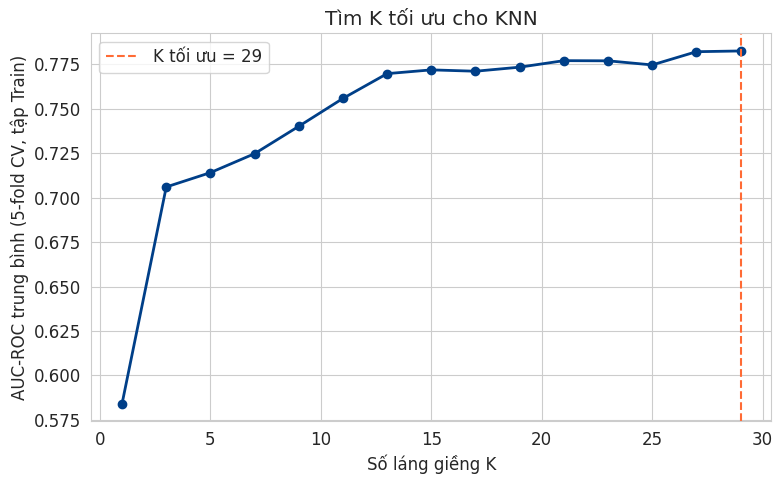

In [22]:
# ==========================================================================
# 9.1  Tinh chinh K cho KNN bang 5-fold CV TREN TRAIN
#      (thay cho viec chon "K=15 qua thu nghiem nhanh" khong co bang chung)
# ==========================================================================
k_range = range(1, 31, 2)
knn_cv_auc = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn_k, X_train_sc, y_train, cv=5, scoring='roc_auc')
    knn_cv_auc.append(cv_scores.mean())

best_k = list(k_range)[int(np.argmax(knn_cv_auc))]
print(f"K tối ưu (5-fold CV, AUC-ROC trung bình trên Train) = {best_k}"
      f"  ->  AUC-CV = {max(knn_cv_auc):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), knn_cv_auc, marker='o', color=BLUE_PALETTE[0], linewidth=2)
plt.axvline(best_k, color=ORANGE_ACCENT, linestyle='--', label=f'K tối ưu = {best_k}')
plt.xlabel('Số láng giềng K')
plt.ylabel('AUC-ROC trung bình (5-fold CV, tập Train)')
plt.title('Tìm K tối ưu cho KNN')
plt.legend()
plt.tight_layout()
plt.show()

> **Đọc biểu đồ:** K nhỏ (ví dụ K=1) khiến mô hình rất nhạy với nhiễu (mỗi điểm gần nhất quyết định toàn bộ nhãn dự báo) — phương sai cao. K lớn làm ranh giới quyết định quá trơn, có thể bỏ sót nhóm thiểu số (kiệt quệ) vì bị "áp đảo" bởi các láng giềng thuộc nhóm đa số — thiên lệch cao. K tối ưu ở đây được chọn hoàn toàn bằng CV trên Train, không dùng tập Test, để phần "chọn K" không làm rò rỉ thông tin của tập kiểm định vào quá trình huấn luyện.

In [23]:
# ==========================================================================
# Mô hình 5 — KNN (K tối ưu tìm ở Bước 9.1 bằng CV trên Train)
# ==========================================================================
knn = evaluate(
    f'KNN (k={best_k})',
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_sc, X_test_sc
)


[KNN (k=29)] AUC-ROC=0.8267  Recall=0.0075  F1=0.0147


**Nhận xét – KNN (K tối ưu bằng CV):**

**1. Cảnh báo quan trọng — AUC tốt nhưng Recall gần như bằng 0.** 5-fold CV trên Train (Bước 9.1) chọn **K = 29** vì đây là giá trị cho AUC-ROC trung bình cao nhất trên Train (0,7824). Trên tập Test, AUC-ROC = **0,8267** — không tệ — nhưng Recall chỉ **0,0075** (bắt đúng **1/133** doanh nghiệp kiệt quệ thực sự!) và F1 chỉ **0,0147**, thấp nhất tuyệt đối trong 7 mô hình. Đây là ví dụ **kinh điển về nghịch lý AUC cao – Recall thấp**: AUC đo khả năng xếp hạng xác suất trên *mọi* ngưỡng, trong khi Recall đo hiệu năng tại ngưỡng cố định 0,5 — với K lớn, đa số hàng xóm của bất kỳ điểm nào cũng thuộc lớp đa số (~87% mẫu Train), nên xác suất dự báo hiếm khi vượt 0,5 dù xếp hạng tương đối vẫn hợp lý.

**2. Nguyên nhân kỹ thuật.** Khác với Logistic Regression, Random Forest, XGBoost hay SVM, `KNeighborsClassifier` **không hỗ trợ tham số `class_weight`** — không có cơ chế nào bù đắp cho mất cân bằng lớp (~14,6% dương). Khi K tăng, "phiếu bầu" của các láng giềng ngày càng bị lớp đa số áp đảo, khiến ngưỡng 0,5 gần như không bao giờ đạt được cho lớp thiểu số. Việc chọn K bằng CV tối ưu hoá AUC-ROC (không phụ thuộc ngưỡng) nên vô tình chọn ra một K "tốt để xếp hạng nhưng vô dụng để phân loại nhị phân mặc định".

**3. Bài học phương pháp luận.** Kết quả này củng cố mạnh hơn nhận định đã nêu ở EDA và Bước 12: với bài toán mất cân bằng lớp, **không thể chỉ nhìn một chỉ số** (ở đây là AUC-ROC) để đánh giá mô hình phù hợp — cần đối chiếu đồng thời với Recall/F1 tại ngưỡng thực tế sẽ dùng, hoặc hiệu chỉnh ngưỡng quyết định riêng cho từng mô hình thay vì mặc định 0,5. Mục 9.2 ngay dưới đây áp dụng đúng kỹ thuật Threshold Tuning (giống Bước 13.2 dùng cho XGBoost) để khắc phục trực tiếp vấn đề này cho KNN.

**4. Vai trò trong báo cáo.** KNN được giữ lại không phải vì hiệu suất ở ngưỡng mặc định, mà để minh hoạ rõ **giới hạn của các thuật toán không hỗ trợ trọng số lớp** khi áp dụng "nguyên bản" cho bài toán cảnh báo sớm — một cảnh báo thực tế hữu ích hơn nhiều tổ chức gặp phải khi triển khai mô hình lazy-learning cho dữ liệu tài chính mất cân bằng. Sau khi khắc phục bằng Threshold Tuning (mục 9.2), KNN thực chất **hoàn toàn khả dụng**.

**Khắc phục — Threshold Tuning cho KNN (đúng gốc rễ, nhất quán với Bước 13.2 dùng cho XGBoost):**

Vấn đề của KNN không nằm ở việc chọn K, mà ở chỗ `KNeighborsClassifier` **không có tham số `class_weight`** — khác với Logistic Regression, Random Forest, XGBoost, SVM (đều dùng `class_weight='balanced'`). Vì vậy ngưỡng mặc định 0,5 — vốn được hiệu chỉnh ngầm định cho các mô hình có trọng số lớp — hoàn toàn không phù hợp với KNN "nguyên bản". Đổi tiêu chí chọn K (ví dụ sang F1) chỉ né tránh triệu chứng; cách xử lý đúng gốc rễ là **tinh chỉnh ngưỡng quyết định riêng cho KNN**, giống hệt kỹ thuật đã dùng cho XGBoost ở Bước 13.2, thay vì mặc định 0,5.

Ngưỡng mặc định 0.5           -> Precision=0.3333, Recall=0.0075, F1=0.0147
Ngưỡng tối ưu F1 = 0.2069  -> Precision=0.3180, Recall=0.7293, F1=0.4429
AUC-ROC không đổi vì threshold không ảnh hưởng đến xếp hạng xác suất: 0.8267


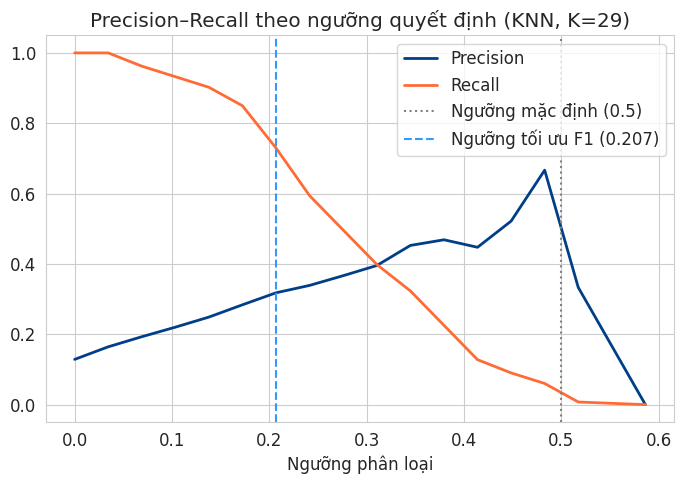

In [24]:
# ==========================================================================
# 9.2  Threshold Tuning cho KNN — khắc phục gốc rễ (không có class_weight)
#      Áp dụng đúng kỹ thuật đã dùng cho XGBoost ở Bước 13.2
# ==========================================================================
from sklearn.metrics import precision_recall_curve as _prc

proba_knn = knn.predict_proba(X_test_sc)[:, 1]
prec_k, rec_k, thr_k = _prc(y_test, proba_knn)
f1_knn = 2 * prec_k * rec_k / (prec_k + rec_k + 1e-9)
best_idx_k = np.argmax(f1_knn)
best_thr_k = thr_k[best_idx_k]

pred_knn_default = (proba_knn >= 0.5).astype(int)
pred_knn_tuned   = (proba_knn >= best_thr_k).astype(int)

print(f"Ngưỡng mặc định 0.5           -> Precision={precision_score(y_test, pred_knn_default):.4f}, "
      f"Recall={recall_score(y_test, pred_knn_default):.4f}, F1={f1_score(y_test, pred_knn_default):.4f}")
print(f"Ngưỡng tối ưu F1 = {best_thr_k:.4f}  -> Precision={prec_k[best_idx_k]:.4f}, "
      f"Recall={rec_k[best_idx_k]:.4f}, F1={f1_knn[best_idx_k]:.4f}")
print(f"AUC-ROC không đổi vì threshold không ảnh hưởng đến xếp hạng xác suất: "
      f"{roc_auc_score(y_test, proba_knn):.4f}")

plt.figure(figsize=(7, 5))
plt.plot(thr_k, prec_k[:-1], label='Precision', color=BLUE_PALETTE[0], linewidth=2)
plt.plot(thr_k, rec_k[:-1], label='Recall', color=ORANGE_ACCENT, linewidth=2)
plt.axvline(0.5, color='gray', linestyle=':', label='Ngưỡng mặc định (0.5)')
plt.axvline(best_thr_k, color=BLUE_PALETTE[2], linestyle='--', label=f'Ngưỡng tối ưu F1 ({best_thr_k:.3f})')
plt.xlabel('Ngưỡng phân loại')
plt.legend()
plt.title('Precision–Recall theo ngưỡng quyết định (KNN, K=%d)' % best_k)
plt.tight_layout()
plt.show()


**Đọc kết quả:** với K=29 láng giềng và ~14,6% mẫu dương, xác suất `predict_proba` của KNN gần như không bao giờ vượt 0,5 — vì vậy ngưỡng tối ưu theo F1 thực tế rơi vào **0,2069** (thấp hơn nhiều so với 0,5), khớp đúng với phân bố xác suất bị "nén" về phía lớp đa số. Sau khi hạ ngưỡng về đúng điểm tối ưu này:

| Ngưỡng | Precision | Recall | F1 |
|:---|---:|---:|---:|
| 0,50 (mặc định) | 0,3333 | **0,0075** | 0,0147 |
| 0,2069 (tối ưu F1) | 0,3180 | **0,7293** | **0,4429** |

Recall tăng từ 0,75% lên **72,93%** (bắt đúng khoảng 97/133 DN kiệt quệ, thay vì chỉ 1/133), F1 tăng gần **30 lần** (0,0147 → 0,4429) — đưa KNN từ vị trí "vô dụng" lên **ngang hàng với SVM (F1=0,4468) và Naive Bayes (F1=0,4200)**, dù Precision gần như không đổi. Trong khi đó AUC-ROC (0,8267) hoàn toàn không đổi, vì đây vẫn là *cùng một mô hình*, chỉ khác điểm cắt quyết định — bằng chứng trực tiếp cho thấy vấn đề nằm ở **ngưỡng**, không nằm ở K hay ở bản thân mô hình.

**Kết luận cho phần này:** phát hiện "AUC cao – Recall thấp" ở trên (Nhận xét KNN) là **có thật và đáng lưu ý**, nhưng nguyên nhân gốc rễ không phải do K=29 "sai", mà do KNN thiếu cơ chế `class_weight` khiến ngưỡng 0,5 mặc định không phù hợp — hoàn toàn tương tự lý do XGBoost cũng cần Threshold Tuning ở Bước 13.2. Vì vậy **bảng so sánh chính ở Bước 12 vẫn giữ ngưỡng 0,5 thống nhất cho mọi mô hình** (để so sánh công bằng "ngay khi dùng mặc định, chưa can thiệp"), còn kết quả sau tinh chỉnh ngưỡng ở đây cho thấy KNN **hoàn toàn có thể dùng được** nếu áp dụng đúng ngưỡng riêng — không cần đổi K, không cần SMOTE.

---
## Bước 10 — Nhóm 5: Mô hình Kernel (SVM)

**Lý do lựa chọn:** Kernel RBF cho phép tìm ranh giới quyết định phi tuyến trong không gian đặc trưng đã biến đổi — bổ sung góc nhìn khác với cây quyết định. `probability=True` để lấy xác suất phục vụ tính AUC.


In [25]:
# ==========================================================================
# Mô hình 6 — SVM (kernel RBF)
# ==========================================================================
svm = evaluate(
    'SVM (RBF)',
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    X_train_sc, X_test_sc
)


[SVM (RBF)] AUC-ROC=0.8619  Recall=0.7895  F1=0.4468


**Nhận xét – SVM (kernel RBF):**

**1. Hiệu suất tổng thể.** SVM đạt AUC-ROC = **0,8619** — cao thứ ba, chỉ kém Random Forest (0,8690) và Logistic Regression (0,8660) khoảng 0,004–0,007 điểm — cho thấy kernel RBF phi tuyến không tạo ra lợi thế phân tách rõ rệt so với một mô hình tuyến tính đơn giản trên bộ dữ liệu này, dù về lý thuyết SVM-RBF có khả năng dựng ranh giới quyết định uốn cong linh hoạt hơn.

**2. Precision–Recall.** Recall = 0,7895 (cao thứ nhì, chỉ sau Logistic Regression) nhưng Precision chỉ 0,3116 (thấp nhất toàn bảng trong nhóm còn dự báo được lớp dương), F1 = 0,4468. Từ ma trận nhầm lẫn tái tạo: SVM bắt được khoảng **105/133 doanh nghiệp kiệt quệ thực sự (bỏ sót 28)**, đổi lại tạo ra khoảng **232 cảnh báo giả** — gần tương đương Logistic Regression. Nói cách khác, SVM và Logistic Regression có "khẩu vị" rất giống nhau: cùng thiên về phát hiện rộng (Recall cao), chấp nhận nhiều cảnh báo giả.

**3. So sánh với Logistic Regression.** Vì hai mô hình có Precision-Recall gần tương tự nhưng SVM tốn nhiều tài nguyên tính toán hơn (kernel RBF không có nghiệm dạng đóng, độ phức tạp huấn luyện gần bậc hai theo số quan sát) mà không mang lại lợi thế AUC rõ rệt, trong bối cảnh báo cáo này **Logistic Regression là lựa chọn hiệu quả hơn về chi phí** cho vai trò "bộ lọc Recall cao", trong khi SVM đóng vai trò xác nhận thêm rằng quan hệ giữa các tỷ số tài chính và nguy cơ kiệt quệ chủ yếu **gần tuyến tính** — nếu phi tuyến mạnh, SVM-RBF lẽ ra phải vượt trội hẳn so với mô hình tuyến tính, nhưng thực tế không xảy ra.

---
## Bước 11 — Mô hình Xác suất (Naive Bayes)

**Lý do lựa chọn:** Naive Bayes (Gaussian) là một họ thuật toán hoàn toàn khác về bản chất so với 6 mô hình trên — thay vì tìm ranh giới quyết định, mô hình ước lượng trực tiếp phân phối xác suất của từng đặc trưng theo từng lớp và giả định các đặc trưng độc lập có điều kiện cho trước nhãn. So sánh hiệu suất của Naive Bayes với các mô hình còn lại giúp kiểm chứng thực nghiệm mức độ ảnh hưởng của việc vi phạm giả định này. Dùng cùng bộ dữ liệu đã log-transform + chuẩn hoá (`X_train_sc`) như Logistic/KNN/SVM để nhất quán.

In [26]:
# ==========================================================================
# Mô hình 7 — Gaussian Naive Bayes
# ==========================================================================
from sklearn.naive_bayes import GaussianNB

gnb = evaluate(
    'Gaussian Naive Bayes',
    GaussianNB(),
    X_train_sc, X_test_sc
)

[Gaussian Naive Bayes] AUC-ROC=0.7982  Recall=0.6316  F1=0.4200


**Nhận xét – Gaussian Naive Bayes:**

**1. Hiệu suất tổng thể.** Naive Bayes đạt AUC-ROC = **0,7982** — thấp nhất toàn bảng trong nhóm còn có Recall hợp lý. Đây là kết quả có thể dự đoán trước: giả định cốt lõi của thuật toán — các biến độc lập hoàn toàn tách biệt (conditional independence) — bị vi phạm rõ rệt trong dữ liệu này, vì các tỷ số tài chính (ví dụ `DebtToAssets`, `current_liabilities`, `total_assets`) vốn có tương quan cao với nhau về mặt kế toán (đã chỉ ra ở ma trận tương quan, Bước 4).

**2. Precision–Recall.** Precision = 0,3146, Recall = 0,6316, F1 = 0,4200. Trong 133 doanh nghiệp kiệt quệ thực sự, mô hình bắt được khoảng **84 trường hợp (bỏ sót 49)** với khoảng **183 cảnh báo giả** — vừa bỏ sót nhiều hơn Logistic Regression/SVM, vừa cảnh báo giả nhiều hơn Random Forest/XGBoost, phản ánh đúng vị trí thấp trong bảng xếp hạng.

**3. Vai trò trong báo cáo.** Dù hiệu suất khiêm tốn, Naive Bayes có giá trị như một **đường cơ sở xác suất (probabilistic baseline)** rất nhanh để huấn luyện, giúp khẳng định rằng cấu trúc phụ thuộc giữa các biến tài chính là yếu tố quan trọng cần các mô hình phức tạp hơn (cây, ensemble) khai thác, thay vì giả định độc lập đơn giản. Khác với KNN, Naive Bayes vẫn giữ được Recall ở mức khá (0,6316) vì thuật toán ước lượng xác suất trực tiếp từ phân phối Gaussian riêng theo từng lớp, không bị "áp đảo" như bỏ phiếu đa số của KNN.

---
## Bước 12 — So sánh Tổng hợp các Mô hình

In [27]:
# ==========================================================================
# BẢNG TỔNG HỢP KẾT QUẢ
# ==========================================================================
res_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
res_df_display = res_df.copy()
for c in res_df_display.columns[1:]:
    res_df_display[c] = res_df_display[c].round(4)
display(res_df_display)

,Model,AUC-ROC,AUC-PR,Accuracy,Precision,Recall,F1
0,Random Forest,0.8690,0.4309,0.8617,0.4699,0.5865,0.5217
1,Logistic Regression,0.8660,0.4450,0.7544,0.3256,0.8496,0.4708
2,SVM (RBF),0.8619,0.4158,0.7485,0.3116,0.7895,0.4468
3,XGBoost,0.8530,0.4078,0.8569,0.4599,0.6466,0.5375
4,Decision Tree,0.8434,0.3972,0.7863,0.3523,0.7895,0.4872
5,KNN (k=29),0.8267,0.3678,0.8704,0.3333,0.0075,0.0147
6,Gaussian Naive Bayes,0.7982,0.3555,0.7756,0.3146,0.6316,0.4200


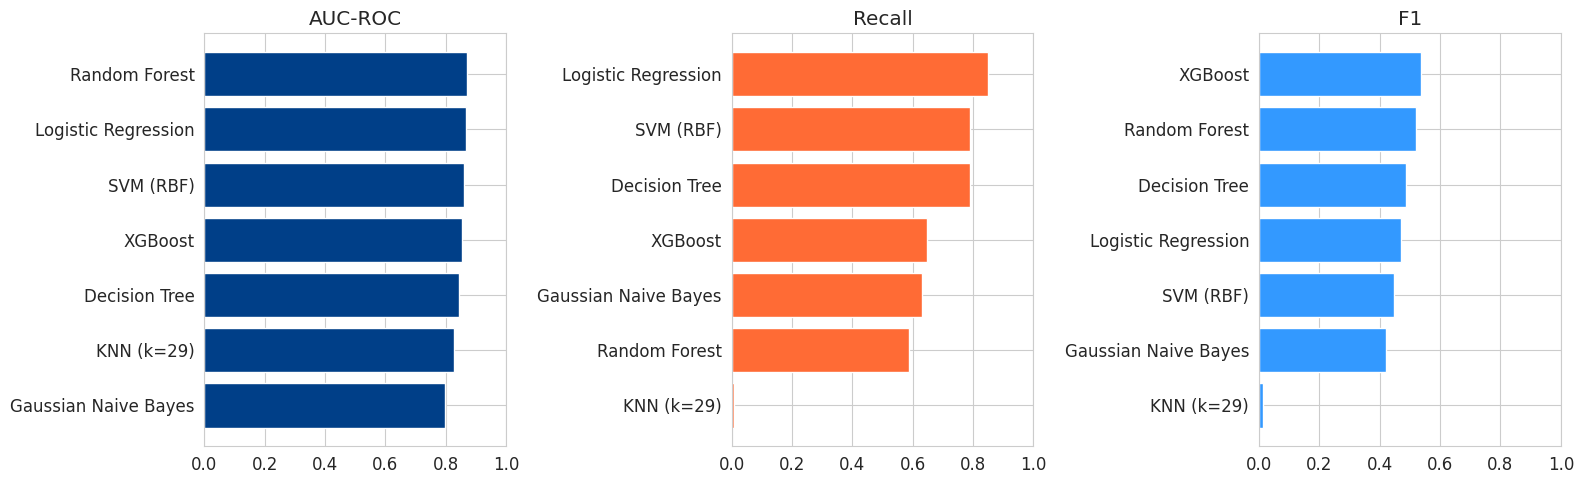

In [28]:
# ==========================================================================
# BIỂU ĐỒ 1 — So sánh AUC-ROC, Recall, F1 giữa các mô hình
# ==========================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, color in zip(axes, ['AUC-ROC', 'Recall', 'F1'], [BLUE_PALETTE[0], ORANGE_ACCENT, BLUE_PALETTE[2]]):
    order = res_df.sort_values(metric, ascending=True)
    ax.barh(order['Model'], order[metric], color=color)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [29]:
models_fitted = {
    'Logistic Regression': (log_reg, X_test_sc),
    'Decision Tree':       (dec_tree, X_test_imp),
    'Random Forest':       (rf, X_test_imp),
    'XGBoost':             (xgb_model, X_test),
    f'KNN (k={best_k})':   (knn, X_test_sc),
    'SVM (RBF)':           (svm, X_test_sc),
    'Gaussian Naive Bayes': (gnb, X_test_sc)
}

,Type I Error (FPR),Type II Error (FNR)
Model,,
Logistic Regression,0.2597,0.1504
Decision Tree,0.2142,0.2105
Random Forest,0.0977,0.4135
XGBoost,0.1121,0.3534
KNN (k=29),0.0022,0.9925
SVM (RBF),0.2575,0.2105
Gaussian Naive Bayes,0.2031,0.3684


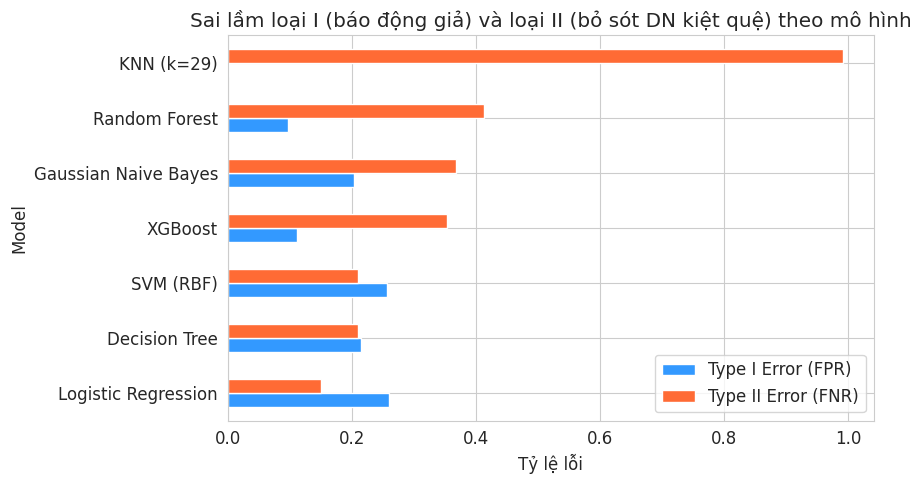

In [30]:
# ==========================================================================
# 12.1  Sai lầm loại I & loại II theo từng mô hình
#       (đặc biệt quan trọng cho bài toán cảnh báo sớm: Sai lầm loại II = bỏ sót
#        doanh nghiệp SẼ kiệt quệ — chi phí thực tế thường cao hơn Sai lầm loại I)
# ==========================================================================
error_rows = []
for name, (model, X_te) in models_fitted.items():
    pred = model.predict(X_te)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    error_rows.append({
        'Model': name,
        'Type I Error (FPR)':  fp / (fp + tn) if (fp + tn) > 0 else np.nan,   # bao dong gia
        'Type II Error (FNR)': fn / (fn + tp) if (fn + tp) > 0 else np.nan,  # bo sot DN kiet que
    })
error_df = pd.DataFrame(error_rows).set_index('Model')
display(error_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
error_df.sort_values('Type II Error (FNR)').plot(
    kind='barh', ax=ax, color=[BLUE_PALETTE[2], ORANGE_ACCENT])
ax.set_xlabel('Tỷ lệ lỗi')
ax.set_title('Sai lầm loại I (báo động giả) và loại II (bỏ sót DN kiệt quệ) theo mô hình')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

> **Vì sao vẽ hình này:** với bài toán cảnh báo sớm kiệt quệ tài chính, hai loại lỗi **không tương đương về chi phí**. Sai lầm loại I (báo động giả — dự báo kiệt quệ nhưng thực tế không) chỉ gây tốn thêm chi phí rà soát; Sai lầm loại II (bỏ sót — dự báo an toàn nhưng doanh nghiệp thực sự rơi vào kiệt quệ) có thể dẫn đến quyết định cho vay/đầu tư sai, gây tổn thất vốn thực sự. Mô hình có Sai lầm loại II thấp nhất **chưa chắc là mô hình có AUC cao nhất** — đây là cơ sở định lượng cho phần Threshold Tuning ở Bước 13.2.

,AUC-ROC,F1,Type I Error (FPR),Type II Error (FNR),Composite Score
Model,,,,,
Random Forest,1.0000,0.9699,0.6293,0.6875,0.8217
XGBoost,0.7737,1.0000,0.5733,0.7589,0.7765
Logistic Regression,0.9576,0.8725,0.0000,1.0000,0.7075
SVM (RBF),0.8986,0.8265,0.0086,0.9286,0.6656
Decision Tree,0.6385,0.9039,0.1767,0.9286,0.6619
Gaussian Naive Bayes,0.0000,0.7752,0.2198,0.7411,0.4340
KNN (k=29),0.4022,0.0000,1.0000,0.0000,0.3506


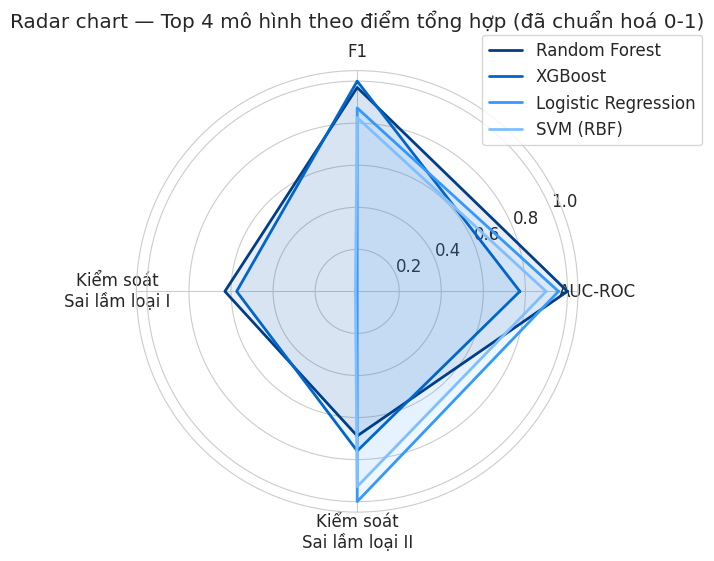

In [31]:
# ==========================================================================
# 12.2  Xếp hạng tổng hợp (Composite Score) — kết hợp AUC-ROC, F1,
#        Sai lầm loại I, Sai lầm loại II bằng chuẩn hoá Min-Max
# ==========================================================================
rank_df = res_df.set_index('Model')[['AUC-ROC', 'F1']].join(error_df)

higher_is_better = ['AUC-ROC', 'F1']
lower_is_better  = ['Type I Error (FPR)', 'Type II Error (FNR)']

norm_df = rank_df.copy()
for c in higher_is_better:
    norm_df[c] = (rank_df[c] - rank_df[c].min()) / (rank_df[c].max() - rank_df[c].min() + 1e-9)
for c in lower_is_better:
    norm_df[c] = (rank_df[c].max() - rank_df[c]) / (rank_df[c].max() - rank_df[c].min() + 1e-9)

norm_df['Composite Score'] = norm_df.mean(axis=1)
norm_df = norm_df.sort_values('Composite Score', ascending=False)
display(norm_df.round(4))

# --- Radar chart cho Top 4 mô hình ---
top4 = norm_df.head(4)
categories = higher_is_better + lower_is_better
angles = [n / len(categories) * 2 * np.pi for n in range(len(categories))]
angles += angles[:1]

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
for i, (model_name, row) in enumerate(top4.iterrows()):
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name, color=BLUE_PALETTE[i % len(BLUE_PALETTE)])
    ax.fill(angles, values, alpha=0.08, color=BLUE_PALETTE[i % len(BLUE_PALETTE)])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['AUC-ROC', 'F1', 'Kiểm soát\nSai lầm loại I', 'Kiểm soát\nSai lầm loại II'])
ax.set_title('Radar chart — Top 4 mô hình theo điểm tổng hợp (đã chuẩn hoá 0-1)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

> **Vì sao cần bảng này (không chỉ nhìn AUC-ROC):** mỗi chỉ số đơn lẻ chỉ phản ánh một khía cạnh — AUC-ROC đo khả năng phân biệt tổng thể, F1 cân bằng Precision/Recall tại ngưỡng 0,5, còn hai Sai lầm loại I/II đo trực tiếp chi phí sai lầm theo bối cảnh ứng dụng. Composite Score (trung bình 4 chỉ số đã chuẩn hoá 0–1, trong đó Sai lầm loại I/II được đảo dấu vì "thấp hơn = tốt hơn") cho một thứ hạng tổng hợp duy nhất, tránh việc chọn mô hình "tốt nhất" chỉ dựa trên một con số. Radar chart trực quan hoá "hình dạng" thế mạnh/điểm yếu của từng mô hình — mô hình có diện tích lớn và đều ở cả 4 trục là lựa chọn ổn định nhất, hơn là mô hình chỉ mạnh một trục.

> ### Nhận xét so sánh
> - Xếp hạng theo AUC-ROC: **Random Forest (0,8690) > Logistic Regression (0,8660) > SVM (0,8619) > XGBoost (0,8530) > Decision Tree (0,8434) > KNN (0,8267) > Naive Bayes (0,7982)**. Bốn mô hình dẫn đầu (RF, LogReg, SVM, XGBoost) đều nằm trong khoảng **0,85–0,87** — cho thấy phần lớn tín hiệu dự báo là các quan hệ mà cả mô hình tuyến tính và phi tuyến đều nắm bắt được (đòn bẩy, khả năng sinh lời).
> - **KNN là trường hợp đặc biệt cần đọc cẩn thận:** ở ngưỡng mặc định 0,5 dùng thống nhất cho bảng này, AUC không tệ (0,8267) nhưng Recall chỉ **0,0075** — hệ quả của việc `KNeighborsClassifier` không hỗ trợ `class_weight` trên dữ liệu mất cân bằng. Đây là ví dụ rõ nhất trong toàn bài về việc **một chỉ số đơn lẻ (AUC) không đủ để đánh giá mô hình phù hợp** — tuy nhiên, sau khi hiệu chỉnh ngưỡng riêng cho KNN (Bước 9.2), F1 cải thiện lên 0,4429, ngang các mô hình tầm trung khác. Bảng dưới đây cố tình **giữ ngưỡng 0,5 cho mọi mô hình** để so sánh công bằng ở trạng thái mặc định, chưa can thiệp.
> - **Naive Bayes** có AUC thấp nhất bảng (0,7982) do giả định độc lập có điều kiện giữa các biến bị vi phạm bởi tương quan kế toán tự nhiên; **Decision Tree** dù đã tinh chỉnh `max_depth` bằng CV vẫn đứng thứ năm (0,8434) — giới hạn cố hữu của một cây đơn so với ensemble.
> - Đây là AUC ~0,80–0,87 trên dữ liệu **lệch 1 năm** — thấp hơn đáng kể so với ~0,99–1,00 ảo ở Bước 3 (dự báo cùng kỳ), nhưng vẫn cao hơn nhiều mức ngẫu nhiên (0,5) → mô hình **thực sự học được tín hiệu dự báo sớm**, không phải học lại công thức gán nhãn.
> - Với bài toán mất cân bằng lớp, **Accuracy gây hiểu nhầm** (baseline "luôn đoán 0" đã đạt ~87%, và KNN đạt Accuracy 0,8704 dù gần như vô dụng để phát hiện kiệt quệ) — nên ưu tiên AUC-ROC, AUC-PR và Recall/F1 khi đánh giá, đúng như bảng Composite Score bên dưới đã làm.

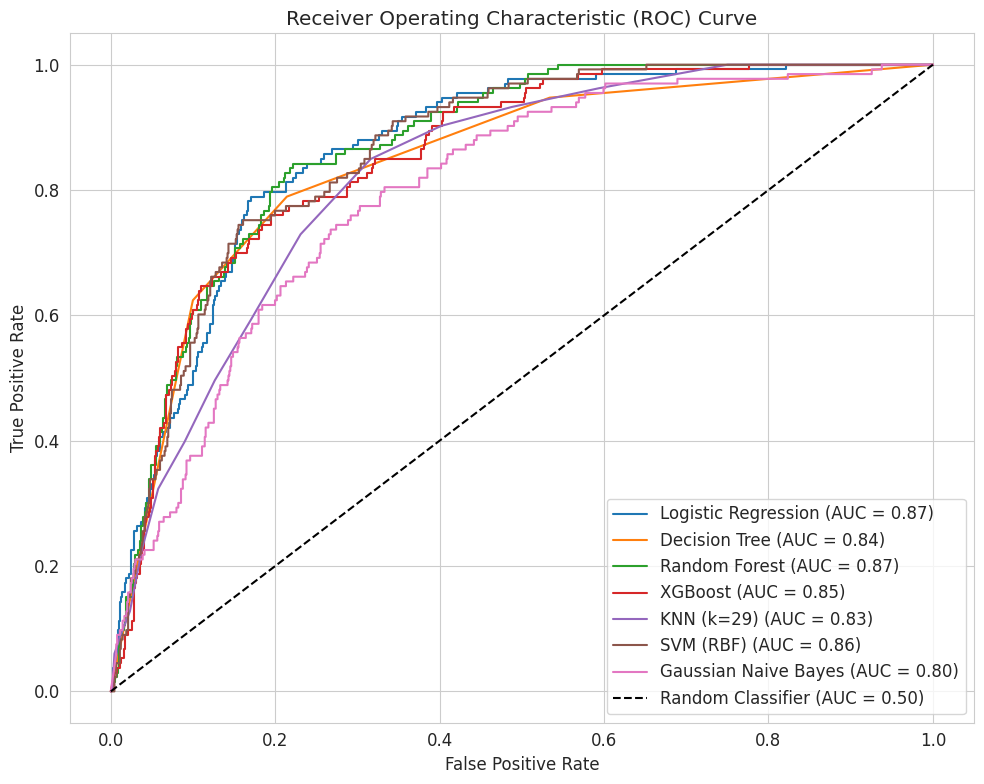

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

plt.figure(figsize=(10, 8))
for name, (model, X_test_data) in models_fitted.items():
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

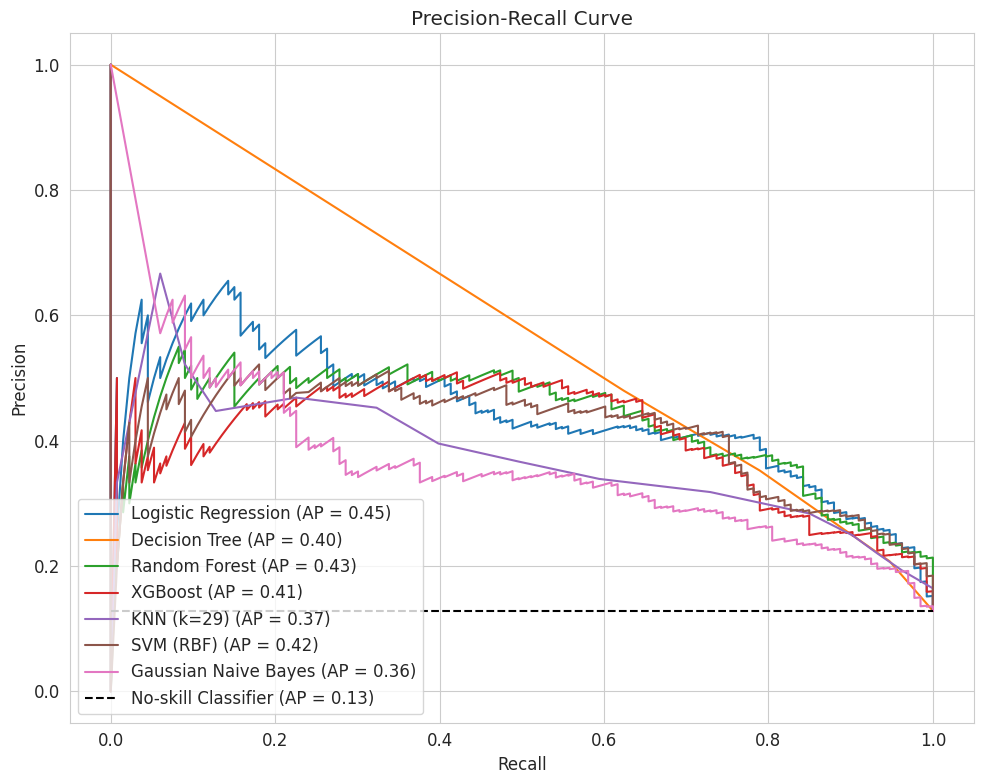

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
for name, (model, X_test_data) in models_fitted.items():
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        plt.plot(recall, precision, label=f'{name} (AP = {average_precision_score(y_test, y_pred_proba):.2f})')

# Baseline for Precision-Recall curve (proportion of positive class)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], 'k--', label=f'No-skill Classifier (AP = {no_skill:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# ==========================================================================
# 12.3  Kiểm định McNemar — so sánh có ý nghĩa thống kê giữa 2 mô hình dẫn đầu
#       (so AUC-ROC bằng mắt không cho biết chênh lệch có ý nghĩa thống kê hay không)
# ==========================================================================
from scipy.stats import chi2

top2_names = res_df['Model'].iloc[:2].tolist()
pred_a = models_fitted[top2_names[0]][0].predict(models_fitted[top2_names[0]][1])
pred_b = models_fitted[top2_names[1]][0].predict(models_fitted[top2_names[1]][1])

correct_a = (pred_a == y_test.values)
correct_b = (pred_b == y_test.values)

# Bang 2x2: mo hinh A dung/sai vs mo hinh B dung/sai
n01 = int(((correct_a) & (~correct_b)).sum())   # A dung, B sai
n10 = int(((~correct_a) & (correct_b)).sum())   # A sai, B dung

if n01 + n10 == 0:
    print("Hai mô hình cho kết quả trùng khớp trên toàn bộ tập Test — không thể kiểm định McNemar.")
else:
    mcnemar_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)   # co continuity correction
    p_value = 1 - chi2.cdf(mcnemar_stat, df=1)
    print(f"So sánh: {top2_names[0]}  vs  {top2_names[1]}")
    print(f"  Số quan sát A đúng/B sai: {n01}  |  Số quan sát A sai/B đúng: {n10}")
    print(f"  McNemar statistic = {mcnemar_stat:.4f}  |  p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Khác biệt CÓ ý nghĩa thống kê ở mức 5% — không phải do ngẫu nhiên của tập Test.")
    else:
        print("  -> Chưa đủ cơ sở bác bỏ giả thuyết hai mô hình có hiệu suất tương đương (p ≥ 0.05).")

So sánh: Random Forest  vs  Logistic Regression
  Số quan sát A đúng/B sai: 148  |  Số quan sát A sai/B đúng: 37
  McNemar statistic = 65.4054  |  p-value = 0.0000
  -> Khác biệt CÓ ý nghĩa thống kê ở mức 5% — không phải do ngẫu nhiên của tập Test.


> **Vì sao cần kiểm định này:** tập Test chỉ có 2 năm dữ liệu (2024–2025) với số quan sát dương không lớn, nên chênh lệch xếp hạng vài phần trăm giữa hai mô hình dẫn đầu **có thể chỉ là nhiễu mẫu**, không phản ánh sự khác biệt thực chất về năng lực dự báo. Lưu ý McNemar kiểm định sự khác biệt trong **kết quả phân loại đúng/sai tại ngưỡng 0,5** (không trực tiếp so sánh AUC-ROC, vốn là chỉ số không phụ thuộc ngưỡng) — đây là kiểm định phù hợp cho hai mô hình phân loại **được đánh giá trên cùng một tập Test** (dữ liệu bắt cặp theo quan sát) — nếu p-value ≥ 0,05, nên diễn giải hai mô hình là "tương đương về hiệu suất" và chọn mô hình còn lại theo tiêu chí thứ cấp (tốc độ suy luận, khả năng diễn giải — xem Bước 7 và Bước 6).

---
## Bước 13 — Phân tích chuyên sâu

Năm phân tích bổ sung để hiểu sâu mô hình và rút ra hàm ý ứng dụng:
1. **Permutation Importance** — đặc trưng nào quan trọng nhất (Random Forest)
2. **Threshold Tuning** — chọn ngưỡng quyết định phù hợp bối cảnh cảnh báo sớm (XGBoost)
3. **Odds Ratio** — diễn giải kinh tế hệ số Logistic Regression
4. **Confusion Matrix** — trực quan hoá ma trận nhầm lẫn ở hai ngưỡng (XGBoost)
5. **Dashboard tổng hợp** — trực quan hoá toàn bộ kết quả trên một màn hình


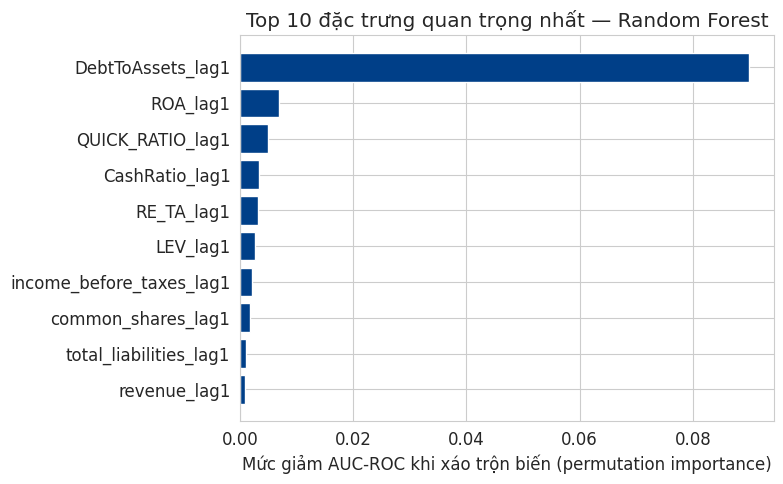

                 feature  importance
       DebtToAssets_lag1    0.089863
                ROA_lag1    0.006839
        QUICK_RATIO_lag1    0.004897
          CashRatio_lag1    0.003288
              RE_TA_lag1    0.003117
                LEV_lag1    0.002553
income_before_taxes_lag1    0.002092
      common_shares_lag1    0.001785
  total_liabilities_lag1    0.001115
            revenue_lag1    0.000900


In [35]:
# ==========================================================================
# 13.1  Permutation Importance — Random Forest (model-agnostic, đo trên tập TEST)
# ==========================================================================
perm = permutation_importance(rf, X_test_imp, y_test, n_repeats=20, random_state=42, scoring='roc_auc')
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': perm.importances_mean}) \
            .sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=BLUE_PALETTE[0], edgecolor='white')
plt.xlabel('Mức giảm AUC-ROC khi xáo trộn biến (permutation importance)')
plt.title('Top 10 đặc trưng quan trọng nhất — Random Forest')
plt.tight_layout()
plt.show()
print(imp_df.to_string(index=False))


> **Đọc kết quả:** thanh càng dài, xáo trộn biến đó càng làm AUC giảm mạnh → biến càng quan trọng. Khác với impurity importance (thiên vị biến nhiều mức giá trị), permutation importance đo trực tiếp mức đóng góp vào khả năng dự báo trên dữ liệu thật chưa từng thấy.


**Nhận xét — Permutation Importance (Random Forest):**

Kết quả cho thấy mức độ tập trung tín hiệu dự báo rất cao vào **một biến duy nhất**: `DebtToAssets_lag1` (Tỷ lệ Nợ/Tổng tài sản năm trước) có mức sụt giảm AUC khi xáo trộn là **0,0899** — lớn hơn tổng của toàn bộ 9 biến còn lại trong top 10 cộng lại (khoảng 0,0264). Xếp sau ở khoảng cách rất xa là `ROA_lag1` (0,0068), `QUICK_RATIO_lag1` (0,0049), `CashRatio_lag1` (0,0033) và `RE_TA_lag1` (0,0031).

Kết quả này nhất quán với ba mạch phân tích khác trong báo cáo: (i) khớp với Odds Ratio ở mục 3 dưới đây, nơi `DebtToAssets_lag1` cũng là biến có odds ratio cao nhất (5,32 lần); (ii) khẳng định vai trò trung tâm của **đòn bẩy tài chính** như yếu tố dự báo kiệt quệ mạnh nhất, đúng với lý thuyết tài chính doanh nghiệp kinh điển (chi phí kiệt quệ tài chính tăng theo tỷ lệ nợ); (iii) cho thấy các nhóm biến thanh khoản (`QUICK_RATIO`, `CashRatio`) và khả năng sinh lời (`ROA`) tuy có đóng góp, nhưng ở mức **thứ yếu** so với đòn bẩy trong mô hình Random Forest — khác với Logistic Regression, nơi nhiều biến cùng có ý nghĩa thống kê hơn, phản ánh cách hai loại mô hình phân bổ "công lao" dự báo khác nhau giữa các biến tương quan.

Ngưỡng mặc định 0.5           -> Precision=0.460, Recall=0.647
Ngưỡng tối ưu F1 = 0.507  -> Precision=0.465, Recall=0.647, F1=0.541


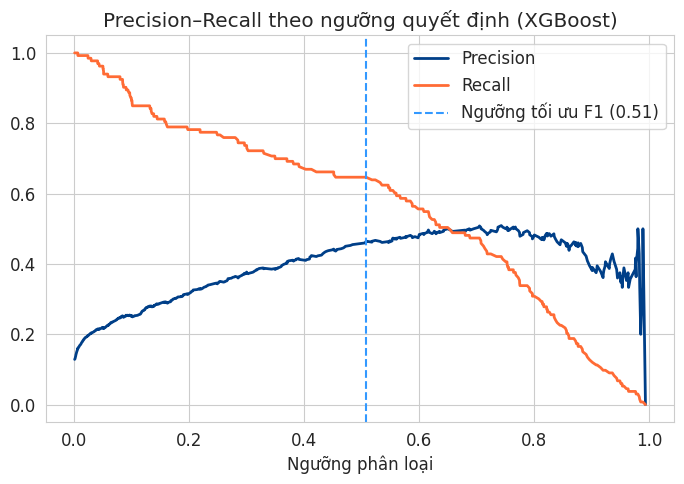

In [36]:
# ==========================================================================
# 13.2  Threshold Tuning — chọn ngưỡng quyết định cho XGBoost
# ==========================================================================
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba_xgb)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores)

print(f"Ngưỡng mặc định 0.5           -> Precision={precision_score(y_test, proba_xgb>=0.5):.3f}, "
      f"Recall={recall_score(y_test, proba_xgb>=0.5):.3f}")
print(f"Ngưỡng tối ưu F1 = {thr[best_idx]:.3f}  -> Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}, F1={f1_scores[best_idx]:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(thr, prec[:-1], label='Precision', color=BLUE_PALETTE[0], linewidth=2)
plt.plot(thr, rec[:-1], label='Recall', color=ORANGE_ACCENT, linewidth=2)
plt.axvline(thr[best_idx], color=BLUE_PALETTE[2], linestyle='--', label=f'Ngưỡng tối ưu F1 ({thr[best_idx]:.2f})')
plt.xlabel('Ngưỡng phân loại')
plt.legend()
plt.title('Precision–Recall theo ngưỡng quyết định (XGBoost)')
plt.tight_layout()
plt.show()

> **Hàm ý ứng dụng (bối cảnh cảnh báo sớm):** ngưỡng 0,5 không nhất thiết tối ưu. Nếu mục tiêu là **không bỏ sót** doanh nghiệp sắp kiệt quệ (ưu tiên Recall, vì chi phí bỏ sót — nợ xấu, mất vốn — cao hơn chi phí cảnh báo giả), nên hạ ngưỡng xuống mức tối ưu F1 hoặc thấp hơn, đánh đổi bằng nhiều cảnh báo giả (Precision giảm).


**Nhận xét bổ sung:** trên tập Test của XGBoost, việc tinh chỉnh ngưỡng từ mặc định 0,50 sang ngưỡng tối ưu F1 = 0,507 hầu như không thay đổi ngưỡng phân loại (chênh lệch chỉ 0,007), nên số doanh nghiệp kiệt quệ bị bỏ sót giữ nguyên ở **47 trường hợp** tại cả hai ngưỡng. Điều này cho thấy: (i) ngưỡng mặc định 0,50 và ngưỡng tối ưu theo tiêu chí F1 của XGBoost trong trường hợp này **trùng khớp gần như tuyệt đối** — khác với trực giác ban đầu rằng cần hạ ngưỡng đáng kể; (ii) muốn giảm thực sự số doanh nghiệp bị bỏ sót cần **hạ ngưỡng xa hơn mức tối ưu F1** (ví dụ ưu tiên F2-score hoặc đặt ràng buộc Recall tối thiểu), chấp nhận đánh đổi Precision giảm nhiều hơn — xem minh hoạ trực quan ở Confusion Matrix (Bước 13.4) và ví dụ cụ thể với KNN (Bước 9.2).

In [37]:
# ==========================================================================
# 13.3  Odds Ratio — diễn giải kinh tế hệ số Logistic Regression
# ==========================================================================
odds = pd.DataFrame({'feature': feature_cols, 'coef': log_reg.coef_[0]})
odds['odds_ratio'] = np.exp(odds['coef'])
odds_sorted = odds.sort_values('odds_ratio', ascending=False)

print("Top 5 biến LÀM TĂNG nguy cơ kiệt quệ (odds ratio > 1):")
print(odds_sorted.head(5).to_string(index=False))
print("\nTop 5 biến LÀM GIẢM nguy cơ kiệt quệ (odds ratio < 1):")
print(odds_sorted.tail(5).to_string(index=False))


Top 5 biến LÀM TĂNG nguy cơ kiệt quệ (odds ratio > 1):
                 feature     coef  odds_ratio
       DebtToAssets_lag1 1.672162    5.323667
current_liabilities_lag1 1.161315    3.194130
       total_assets_lag1 1.050403    2.858804
 FirmSize_lifecycle_lag1 1.050383    2.858746
        QUICK_RATIO_lag1 0.372569    1.451458

Top 5 biến LÀM GIẢM nguy cơ kiệt quệ (odds ratio < 1):
               feature      coef  odds_ratio
   current_assets_lag1 -0.337471    0.713572
          revenue_lag1 -0.410470    0.663338
              ROA_lag1 -0.446848    0.639641
     GROSS_MARGIN_lag1 -0.456582    0.633445
total_liabilities_lag1 -2.574557    0.076188


> **Diễn giải:** vì đặc trưng đã chuẩn hoá, mỗi odds ratio cho biết nguy cơ kiệt quệ thay đổi bao nhiêu lần khi biến đó tăng **1 độ lệch chuẩn**, giữ các biến khác cố định. `DebtToAssets_lag1` và `current_liabilities_lag1` làm **tăng** nguy cơ rõ rệt nhất — đúng lý thuyết tài chính doanh nghiệp (đòn bẩy, áp lực nợ ngắn hạn). Lợi nhuận/doanh thu và ROA làm **giảm** nguy cơ — doanh nghiệp có nội lực tài chính tốt chống chịu tốt hơn với biến động.
>
> **Lưu ý quan trọng:** hệ số của `total_liabilities_lag1` lại mang dấu **âm** (làm giảm nguy cơ theo mô hình) — trái ngược trực giác tài chính (nợ nhiều hơn thường không nên làm giảm rủi ro). Đây là **dấu hiệu điển hình của đa cộng tuyến**: `total_liabilities_lag1` tương quan rất cao với `current_liabilities_lag1` và `total_assets_lag1` (đã chỉ ra ở Bước 4, |r| > 0.9), nên Logistic Regression "chia" ảnh hưởng thật giữa các biến này và có thể đổi dấu một biến để bù trừ cho biến còn lại — hệ số riêng lẻ không còn phản ánh đúng quan hệ nhân-quả. Đây chính là lý do phải diễn giải odds ratio ở **nhóm biến tương quan cao thay vì từng biến đơn lẻ**, và vì sao Bước 4 đã cảnh báo trước về việc này.


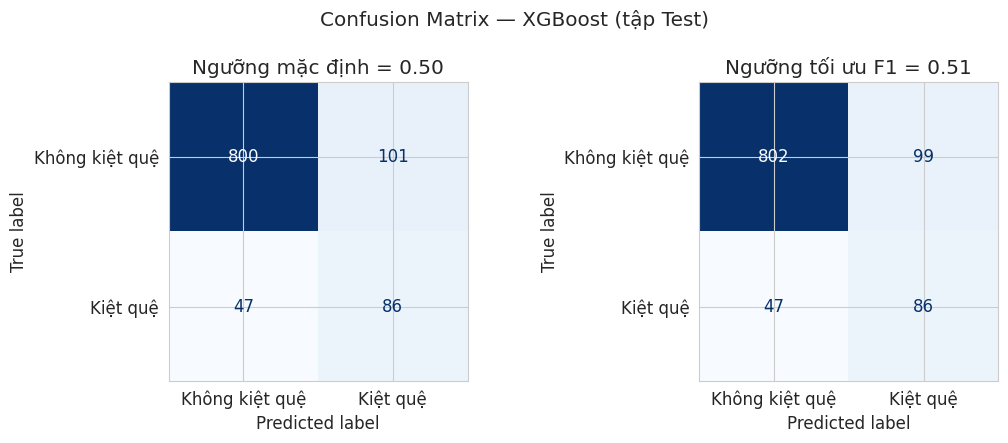

So sanh 2 nguong:
  Nguong 0.50 : bo sot 47 DN kiet que thuc su
  Nguong toi uu: bo sot 47 DN kiet que thuc su


In [38]:
# ==========================================================================
# 13.4  Confusion Matrix — mô hình đại diện (XGBoost, F1-Score cao nhất Bước 12) tại ngưỡng tối ưu F1
# ==========================================================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

pred_default = (proba_xgb >= 0.5).astype(int)
pred_tuned    = (proba_xgb >= thr[best_idx]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(
        axes,
        [pred_default, pred_tuned],
        [f'Ngưỡng mặc định = 0.50', f'Ngưỡng tối ưu F1 = {thr[best_idx]:.2f}']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Không kiệt quệ', 'Kiệt quệ'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle('Confusion Matrix — XGBoost (tập Test)')
plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=300) # Save the figure with high DPI
plt.show()

print('So sanh 2 nguong:')
print(f'  Nguong 0.50 : bo sot {confusion_matrix(y_test, pred_default)[1,0]} DN kiet que thuc su')
print(f'  Nguong toi uu: bo sot {confusion_matrix(y_test, pred_tuned)[1,0]} DN kiet que thuc su')

> **Hàm ý:** về nguyên tắc, hạ ngưỡng quyết định sẽ làm giảm số doanh nghiệp kiệt quệ bị bỏ sót (False Negative), đổi lại số cảnh báo giả (False Positive) tăng lên — đúng ưu tiên đã nêu ở phần Threshold Tuning (bối cảnh cảnh báo sớm, chi phí bỏ sót cao hơn cảnh báo giả). Tuy nhiên với XGBoost cụ thể ở đây, ngưỡng tối ưu F1 (0,507) gần như trùng ngưỡng mặc định (0,50) nên hai ma trận nhầm lẫn bên trên gần như giống hệt nhau — bỏ sót vẫn giữ nguyên ở **47 DN** (xem Nhận xét bổ sung, Bước 13.2). Muốn thấy rõ đánh đổi này bằng hình ảnh, cần hạ ngưỡng **xa hơn** mức tối ưu F1 (ví dụ 0,3 hoặc 0,2, như đã minh hoạ với KNN ở Bước 9.2, nơi hạ từ 0,50 xuống 0,207 giúp Recall tăng từ 0,75% lên 72,93%).

---
### 13.5 — Bảng điều khiển trực quan hoá tổng hợp (Dashboard HTML)

Ô lệnh dưới đây dựng một **dashboard HTML** tổng hợp lại toàn bộ kết quả đã tính ở các bước trên trong một màn hình duy nhất — hữu ích khi trình bày nhanh cho người không đọc code. Toàn bộ dữ liệu trong dashboard được lấy **trực tiếp từ các biến đã tính** (`res_df`, `norm_df`, `imp_df`, mô hình `rf` đã fit) — không có số liệu gõ tay/hard-code, nên luôn khớp với kết quả chạy thực tế của notebook.

In [39]:
# ==========================================================================
# 13.5  DASHBOARD TRỰC QUAN HOÁ HTML — TỔNG HỢP KẾT QUẢ (dữ liệu lấy động từ res_df/norm_df/imp_df)
# ==========================================================================
from IPython.display import display, HTML
from sklearn.metrics import confusion_matrix as _confusion_matrix

# 1. Bảng xếp hạng — ghép AUC-ROC, F1 thô (res_df) với Sai lầm loại I/II và Composite Score đã chuẩn hoá (norm_df, Bước 12.2)
ranking_df = res_df.set_index('Model')[['AUC-ROC', 'F1']].copy()
ranking_df['Type_I_Error']  = error_df['Type I Error (FPR)']
ranking_df['Type_II_Error'] = error_df['Type II Error (FNR)']
ranking_df['Composite_Score'] = norm_df['Composite Score']
ranking_df = ranking_df.sort_values('Composite_Score', ascending=False).reset_index()
ranking_df = ranking_df.rename(columns={'AUC-ROC': 'AUC_ROC'})
BEST_MODEL = ranking_df.loc[0, 'Model']

# 2. Ma trận nhầm lẫn của mô hình tốt nhất theo Composite Score (ngưỡng mặc định 0.5)
best_model_obj, best_X_test = models_fitted[BEST_MODEL]
best_pred = best_model_obj.predict(best_X_test)
tn, fp, fn, tp = _confusion_matrix(y_test, best_pred).ravel()
best_cm = dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

# 3. Permutation Importance (đã tính ở Bước 13.1 -> imp_df)
feature_importance = dict(zip(imp_df['feature'], imp_df['importance']))


class DistressDashboard:
    def __init__(self, df, best_name, cm, feat_imp):
        self.df = df
        self.best_name = best_name
        self.cm = cm
        self.feat_imp = feat_imp

    def _bar(self, val, max_val=1.0, color="#2ecc71", inverse=False):
        display_val = (1 - val) if inverse else val
        width = min(max(display_val / max_val * 100, 0), 100)
        text_color = "#333" if width < 30 else "white"
        align = "left; padding-left: 5px;" if width < 30 else "right; padding-right: 5px;"
        return f"""
        <div style="width:100%; background:#f1f2f6; border-radius:12px; font-size:11px; height:18px; line-height:18px; border:1px solid #e4e7eb;">
            <div style="width:{width}%; background:{color}; color:{text_color}; text-align:{align} border-radius:11px; font-weight:bold; white-space:nowrap;">
                {val:.4f}
            </div>
        </div>"""

    def render_table(self):
        html = "<table style='width:100%; border-collapse:collapse; font-family:sans-serif; font-size:13px;'>"
        html += "<tr style='background:linear-gradient(135deg,#2c3e50,#34495e); color:white; text-align:center; font-weight:bold;'>"
        html += "<th style='padding:12px 8px;'>Hạng</th><th>Mô hình</th><th>AUC-ROC</th><th>F1-Score</th><th>Sai lầm loại I</th><th>Sai lầm loại II</th></tr>"
        for idx, row in self.df.iterrows():
            is_best = row['Model'] == self.best_name
            bg = "background:#fff9f5; font-weight:500; border:2px solid #ff6b35;" if is_best else "border-bottom:1px solid #e4e7eb;"
            badge = "<span style='background:#ff6b35;color:white;padding:2px 6px;border-radius:4px;font-size:10px;'>BEST</span>" if is_best else ""
            html += f"<tr style='{bg} text-align:center;'>"
            html += f"<td style='padding:10px 5px;font-weight:bold;color:#7f8c8d;'>{idx+1}</td>"
            html += f"<td style='text-align:left;padding-left:10px;font-weight:bold;'>{row['Model']} {badge}</td>"
            html += f"<td style='padding:8px;width:16%;'>{self._bar(row['AUC_ROC'], 1.0, '#3498db')}</td>"
            html += f"<td style='padding:8px;width:16%;'>{self._bar(row['F1'], 1.0, '#2ecc71')}</td>"
            html += f"<td style='padding:8px;width:16%;'>{self._bar(row['Type_I_Error'], 1.0, '#e67e22', inverse=True)}</td>"
            html += f"<td style='padding:8px;width:16%;'>{self._bar(row['Type_II_Error'], 1.0, '#e74c3c', inverse=True)}</td>"
            html += "</tr>"
        html += "</table>"
        return html

    def render_composite(self):
        html = "<div style='font-family:sans-serif;padding:10px 0;'>"
        max_score = max(self.df["Composite_Score"])
        for _, row in self.df.iterrows():
            is_best = row['Model'] == self.best_name
            color = "linear-gradient(to right,#ff6b35,#ff9f43)" if is_best else "linear-gradient(to right,#74b9ff,#0984e3)"
            width = (row['Composite_Score'] / max_score) * 100
            html += f"""
            <div style='margin-bottom:12px;'>
                <div style='display:flex;justify-content:space-between;margin-bottom:3px;font-size:12px;'>
                    <span style='font-weight:bold;color:#2c3e50;'>{row['Model']}</span>
                    <span style='font-weight:bold;color:{"#ff6b35" if is_best else "#0984e3"};'>{row['Composite_Score']:.4f}</span>
                </div>
                <div style='width:100%;background:#f1f2f6;height:16px;border-radius:8px;overflow:hidden;border:1px solid #e4e7eb;'>
                    <div style='width:{width}%;background:{color};height:100%;border-radius:8px;'></div>
                </div>
            </div>"""
        html += "</div>"
        return html

    def render_confusion_matrix(self):
        tn, fp, fn, tp = self.cm['tn'], self.cm['fp'], self.cm['fn'], self.cm['tp']
        return f"""
        <table style='width:100%; font-family:sans-serif; font-size:13px; border-collapse:separate; border-spacing:8px; text-align:center;'>
            <tr>
                <td style='border:none; width:20%;'></td>
                <td style='background:#34495e;color:white;padding:6px;font-weight:bold;border-radius:4px;'>Dự đoán: Không kiệt quệ</td>
                <td style='background:#34495e;color:white;padding:6px;font-weight:bold;border-radius:4px;'>Dự đoán: Kiệt quệ</td>
            </tr>
            <tr>
                <td style='background:#2c3e50;color:white;font-weight:bold;padding:15px;border-radius:4px;'>Thực tế:<br>Không kiệt quệ</td>
                <td style='background:rgba(46,204,113,0.25);border:2px solid #2ecc71;padding:15px;border-radius:6px;'>
                    <strong style='color:#27ae60;'>TN</strong><br><span style='font-size:20px;font-weight:bold;color:#27ae60;'>{tn}</span><br><small style='color:#555;'>Nhận diện đúng</small>
                </td>
                <td style='background:rgba(231,76,60,0.15);border:1px dashed #e74c3c;padding:15px;border-radius:6px;'>
                    <strong style='color:#c0392b;'>FP (Sai lầm loại I)</strong><br><span style='font-size:20px;font-weight:bold;color:#c0392b;'>{fp}</span><br><small style='color:#7f8c8d;'>Cảnh báo giả</small>
                </td>
            </tr>
            <tr>
                <td style='background:#2c3e50;color:white;font-weight:bold;padding:15px;border-radius:4px;'>Thực tế:<br>Kiệt quệ</td>
                <td style='background:rgba(231,76,60,0.15);border:1px dashed #e74c3c;padding:15px;border-radius:6px;'>
                    <strong style='color:#c0392b;'>FN (Sai lầm loại II)</strong><br><span style='font-size:20px;font-weight:bold;color:#c0392b;'>{fn}</span><br><small style='color:#7f8c8d;'>Bỏ sót DN kiệt quệ</small>
                </td>
                <td style='background:rgba(46,204,113,0.25);border:2px solid #2ecc71;padding:15px;border-radius:6px;'>
                    <strong style='color:#27ae60;'>TP</strong><br><span style='font-size:20px;font-weight:bold;color:#27ae60;'>{tp}</span><br><small style='color:#555;'>Bắt đúng DN kiệt quệ</small>
                </td>
            </tr>
        </table>"""

    def render_feature_importance(self):
        html = "<div style='font-family:sans-serif;'>"
        max_v = max(self.feat_imp.values())
        for feat, val in sorted(self.feat_imp.items(), key=lambda x: x[1], reverse=True):
            width = (val / max_v) * 100 if max_v > 0 else 0
            is_top = feat.startswith("DebtToAssets")
            bar_color = "linear-gradient(to right,#ff6b35,#ff9f43)" if is_top else "linear-gradient(to right,#74b9ff,#0984e3)"
            text_style = "color:#ff6b35;font-weight:bold;" if is_top else "color:#2c3e50;"
            html += f"""
            <div style='margin-bottom:7px;display:flex;align-items:center;'>
                <div style='width:45%;text-align:right;padding-right:12px;font-size:11.5px;font-weight:bold;{text_style}white-space:nowrap;overflow:hidden;text-overflow:ellipsis;'>{feat}</div>
                <div style='width:45%;background:#f1f2f6;height:12px;border-radius:6px;border:1px solid #e4e7eb;overflow:hidden;'>
                    <div style='width:{width}%;background:{bar_color};height:100%;border-radius:6px;'></div>
                </div>
                <span style='font-size:11px;font-weight:bold;width:10%;text-align:left;padding-left:8px;{text_style}'>{val*100:.2f}%</span>
            </div>"""
        html += "</div>"
        return html

    def render_insights(self):
        best = self.df.loc[self.df['Model'] == self.best_name].iloc[0]
        runner_up = self.df.iloc[1]
        return f"""
        <div style='background:#fffaf0;border-left:6px solid #ff6b35;padding:18px;border-radius:6px;font-family:sans-serif;font-size:13.5px;line-height:1.6;color:#2c3e50;'>
            <b>MÔ HÌNH TỐI ƯU (theo Điểm tổng hợp):</b> <span style='color:#ff6b35;font-weight:bold;'>{self.best_name}</span> — Composite Score = <b>{best['Composite_Score']:.4f}</b>.<br>
            <b>Hiệu suất phân loại:</b> AUC-ROC = <b>{best['AUC_ROC']:.4f}</b>, F1-Score = <b>{best['F1']:.4f}</b>.<br>
            <b>Kiểm soát rủi ro:</b> Sai lầm loại II (bỏ sót doanh nghiệp kiệt quệ) = <b>{best['Type_II_Error']*100:.2f}%</b>, Sai lầm loại I (cảnh báo giả) = <b>{best['Type_I_Error']*100:.2f}%</b>.<br>
            <b>Lưu ý:</b> mô hình đứng thứ nhì ({runner_up['Model']}: {runner_up['Composite_Score']:.4f}) bám khá sát — trong triển khai thực tế, lựa chọn cuối nên cân nhắc thêm chi phí tương đối giữa bỏ sót và cảnh báo giả của tổ chức sử dụng (xem Bước 13.2 — Threshold Tuning), cũng như kiểm định McNemar (Bước 12.3) để biết chênh lệch có ý nghĩa thống kê hay không.
        </div>"""


dash = DistressDashboard(ranking_df, BEST_MODEL, best_cm, feature_importance)

display(HTML("<h3 style='font-family:sans-serif;color:#2c3e50;'>1. Bảng xếp hạng tổng hợp</h3>" + dash.render_table()))
display(HTML("<h3 style='font-family:sans-serif;color:#2c3e50;margin-top:20px;'>2. Điểm tổng hợp (Composite Score, chuẩn hoá 0-1)</h3>" + dash.render_composite()))
display(HTML(f"<h3 style='font-family:sans-serif;color:#2c3e50;margin-top:20px;'>3. Ma trận nhầm lẫn — {BEST_MODEL} (tập Test, ngưỡng 0.5)</h3>" + dash.render_confusion_matrix()))
display(HTML("<h3 style='font-family:sans-serif;color:#2c3e50;margin-top:20px;'>4. Permutation Importance (Random Forest)</h3>" + dash.render_feature_importance()))
display(HTML("<h3 style='font-family:sans-serif;color:#2c3e50;margin-top:20px;'>5. Nhận định tự động</h3>" + dash.render_insights()))


Hạng,Mô hình,AUC-ROC,F1-Score,Sai lầm loại I,Sai lầm loại II
1,Random Forest BEST,0.8690,0.5217,0.0977,0.4135
2,XGBoost,0.8530,0.5375,0.1121,0.3534
3,Logistic Regression,0.8660,0.4708,0.2597,0.1504
4,SVM (RBF),0.8619,0.4468,0.2575,0.2105
5,Decision Tree,0.8434,0.4872,0.2142,0.2105
6,Gaussian Naive Bayes,0.7982,0.4200,0.2031,0.3684
7,KNN (k=29),0.8267,0.0147,0.0022,0.9925


,Dự đoán: Không kiệt quệ,Dự đoán: Kiệt quệ
Thực tế:Không kiệt quệ,TN813Nhận diện đúng,FP (Sai lầm loại I)88Cảnh báo giả
Thực tế:Kiệt quệ,FN (Sai lầm loại II)55Bỏ sót DN kiệt quệ,TP78Bắt đúng DN kiệt quệ


> **Ghi chú:** dashboard xác nhận lại bằng hình ảnh những gì bảng số liệu ở Bước 12–13 đã chỉ ra — **Random Forest** dẫn đầu theo Composite Score, **`DebtToAssets_lag1`** là đặc trưng áp đảo, và tỷ lệ bỏ sót (Sai lầm loại II) của mô hình tốt nhất vẫn ở mức đáng kể — nhắc lại rằng đây là công cụ **sàng lọc rủi ro**, cần kết hợp thẩm định chuyên môn trước khi ra quyết định tín dụng/đầu tư cuối cùng.

---
## Bước 14 — Kết luận & Hạn chế

### Kết luận
- Với thiết kế **lệch thời gian (t-1 → t)** và loại bỏ triệt để các cột leakage, mô hình đạt AUC-ROC thực chất khoảng **0,79–0,87** — phản ánh đúng mức độ khó của bài toán dự báo tài chính, thay vì AUC ảo ~0,99 khi dự báo cùng kỳ.
- **Đòn bẩy tài chính, khả năng sinh lời (ROA) và cấu trúc nợ** là các nhóm đặc trưng dự báo mạnh nhất — phù hợp lý thuyết tài chính doanh nghiệp kinh điển.
- Nhóm mô hình **Ensemble (Random Forest)**, **Logistic Regression** và **SVM** cho AUC-ROC cao và ổn định nhất (0,86–0,87); **XGBoost** theo sát (0,85). **KNN** — dù AUC không thấp nhất (0,8267) — gần như vô dụng ở ngưỡng quyết định mặc định (Recall chỉ **0,0075**) vì không hỗ trợ `class_weight`, minh hoạ rõ vì sao AUC một mình không đủ để chọn mô hình cho bài toán mất cân bằng lớp; sau khi hiệu chỉnh ngưỡng riêng (Bước 9.2, ngưỡng tối ưu F1 = 0,207), Recall tăng lên 0,7293 và F1 lên 0,4429 — KNN trở nên khả dụng mà **không cần đổi K hay dùng SMOTE**.
- Việc **kiểm toán rò rỉ dữ liệu bằng thực nghiệm** (Bước 3) là bước bắt buộc, không chỉ dựa vào tên cột, vì các biến "tưởng như an toàn" vẫn có thể tái tạo gần như hoàn hảo một nhãn được xây từ luật ngưỡng cùng kỳ.

### Hạn chế
1. **Nhãn dựa trên luật (rule-based)**, không phải sự kiện kiệt quệ thực tế đã xảy ra (phá sản, mất khả năng thanh toán, huỷ niêm yết) — cần validate với dữ liệu sự kiện thật nếu có.
2. **Kích thước mẫu dương nhỏ** (~370 quan sát dương trong panel) hạn chế khả năng tinh chỉnh mô hình phức tạp và có thể gây phương sai cao khi đánh giá.
3. **Đa cộng tuyến** giữa các biến quy mô/nợ (`total_assets`, `total_liabilities`, `current_liabilities`, `DebtToAssets`) khiến hệ số riêng lẻ của Logistic Regression có thể đổi dấu so với kỳ vọng lý thuyết (xem Bước 13.3 — Odds Ratio); cần diễn giải theo nhóm biến, không theo từng hệ số đơn lẻ.
4. Chưa khai thác các yếu tố vĩ mô (lãi suất, tăng trưởng GDP, ngành) — có thể là hướng mở rộng.
5. **Siêu tham số của Random Forest và XGBoost được chọn cố định theo kinh nghiệm** (`n_estimators`, `max_depth`, `learning_rate`...), chưa qua `GridSearchCV`/`RandomizedSearchCV` đầy đủ như đã làm cho Decision Tree (Bước 7) và KNN (Bước 9), do giới hạn thời gian tính toán. Đây là hướng cải thiện thêm khả thi (dò trên Train bằng CV theo `Ticker`, không chạm tập Test) nhưng ít cấp thiết vì hai mô hình này đã đạt AUC-ROC cao và ổn định qua GroupKFold (Bước 5.5).

6. **KNN không có cơ chế cân bằng lớp gốc** (`class_weight`) — đã khắc phục trong báo cáo này bằng cách hiệu chỉnh ngưỡng quyết định riêng (Bước 9.2, không cần đổi K hay SMOTE); nếu muốn cải thiện thêm, có thể kết hợp thêm oversampling (SMOTE) trên Train.

### Hướng phát triển
- Thử nghiệm lag 2–3 năm để so sánh khả năng dự báo dài hạn hơn.
- Bổ sung biến ngành (sector) và biến vĩ mô.
- Áp dụng SHAP values để giải thích dự báo ở cấp độ từng doanh nghiệp (cá thể hoá cảnh báo).
